# Brain-age error analysis — best LaBraM fine-tune vs. the data

Where, and why, does the brain-age model make its errors? This notebook takes the best
short-schedule run (selected on **validation** case MAE) and examines its errors against the data:

1. **Training dynamics**: the train/val gap (memorization).
2. **Error summary**: window vs. recording level, mean vs. median, by cohort (normal / abnormal), including
   the train split scored in eval mode.
3. **Error and loss distributions**: per sample (window) and per recording, and the tails.
4. **Per-sample view**: spread of the window predictions inside a recording, mean vs. median pooling, and
   position in the recording.
5. **Regression to the mean**: error by age bin against the train sampling density (how over- or
   under-sampled each age is).
6. **Post-hoc bias correction**: fitted on val, applied to test.
7. **Normal vs. abnormal**, and the **spectral correlates** of the residual.
8. **Real EEG**: at the same true age, a recording predicted accurately vs. one predicted too young
   vs. one too old, side by side; the extreme cases; an **interactive explorer**; and a playground.
9. **Run comparison**: predicted vs. true age per decade across the other trained runs (mixup / C-Mixup / EMA / long /
   age-balanced loss).

Setup: scenario D (CAR input, Huber δ=1, lr 1e-4, layer decay 0.65), subject-disjoint split,
5-minute val/test budget per recording (30 × 10 s windows), 60 s trimmed at each end. A recording's
prediction is the mean of its window predictions, which is the metric reported in ClearML.
Predictions are cached in `<run_dir>/analysis/`.

### Conventions

Every loss, metric and derived value is defined by a numbered equation, written as the code
computes it, before it is first used. Equations, tables, figures and figure panels are numbered per
section: Eq. (2.1), Table 2.2, Figure 3.1(b). Figures have at most two panels side by side.
Symbols used throughout:

| symbol | meaning |
|---|---|
| $r$, $w$ | a recording; a 10 s window of a recording |
| $y_r$ | true age of recording $r$ (years, from the EDF header); a window inherits $y_{r,w}=y_r$ |
| $\hat y_{r,w}$ | the model's prediction for window $w$ (years) |
| $\hat y_r$ | the recording prediction, the mean of its window predictions, Eq. (0.10) |
| $e = \hat y - y$ | signed error (years); $e>0$ means predicted too old |
| $\mu_y,\ \sigma_y$ | mean and sample std of the train-window ages (target z-scoring, Eq. (0.2)) |
| $\mathcal{S}$, $n$ | the set being scored (windows or recordings of one split/cohort) and its size |

### How to use it

* **Open**: in VS Code (Remote-SSH to this box), open `notebooks/age_error_analysis.ipynb` and pick
  the kernel **"LaBraM (.venv)"**. Or run JupyterLab on the box,
  `cd /data/code/LaBraM && .venv/bin/jupyter lab --no-browser --port 8888`, then tunnel it:
  `ssh -L 8888:localhost:8888 <box>` and open the printed `http://localhost:8888/...` link.
* **Run**: *Run All* takes about 2 minutes. Predictions are cached per run, and the GPU is needed
  only the first time a run is scored.
* **Play**: change the **Parameters** cell (which run, which ages to compare, which runs to overlay)
  and re-run. Every section after **0. Load** is independent, so re-run just the one you are
  editing. Section 8 has an interactive EEG browser and a playground cell for your own queries.
* **Code**: analysis helpers are in `labram/eval/age_analysis.py`; EEG plots and the explorer are in
  `labram/eval/age_plots.py`. Cells call them with plain arguments, so changing an argument in a cell
  is usually all you need.

## Parameters

In [1]:
import os
DATA_PATH = "/data/datasets/EEG-public/TAUB/TUH_Abnormal/v3.0.0/edf"
CKPT = "../checkpoints"
# Best short-schedule run by validation case MAE (M1: mixup alpha=0.4).
BEST_RUN = os.environ.get("AGE_BEST_RUN", f"{CKPT}/age_M1_short_mixup04_20261007_231716_154")
# Other local runs to compare (skipped when the directory or checkpoint is missing).
COMPARE = {
    "M1 mixup":            f"{CKPT}/age_M1_short_mixup04_20261007_231716_154",
    "M1c C-Mixup":         f"{CKPT}/age_M1c_short_cmixup04_s5_20261008_001050_123",
    "M12 mixup+EMA":       f"{CKPT}/age_M12_short_mixup_ema_20261008_204214_769",
    "L1 mixup+EMA 12ep":   "age_L1_ep12_mixup_ema",
    "B1 balance sqrt-inv": "age_B1_short_balance_sqrtinv",
    "B2 balance inverse":  "age_B2_short_balance_inv",
}
TRAIN_WINDOWS_PER_RECORDING = 10     # train is scored on a per-recording subsample
COMPARE_AGES = [25, 45, 65, 80]      # section 8: true ages for accurate / too young / too old EEG

## Setup

In [2]:
import sys, warnings
sys.path.insert(0, os.path.abspath(".."))
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from labram.eval.age_analysis import (
    CORRECTIONS, POSTERIOR, add_errors, age_bin_labels, apply_bias_correction, assign_age_bin,
    band_powers, common_average_reference, error_by_age_bin, fit_bias_correction, load_age_run,
    load_window, per_recording, pick_examples, read_epoch_log, recording_spectral_features,
    regression_summary, summary_table)
from labram.eval.age_plots import (
    AGE_LIM, AgeExplorer, assert_max_columns, cached_window_predictions, figure_caption, identity,
    numbered_table, panel_labels, plot_pred_by_bin)

SPLIT_COLORS = {"train": "#9e9e9e", "val": "#1f77b4", "test": "#d62728"}
COHORT_COLORS = {"normal": "#2ca02c", "abnormal": "#ff7f0e"}
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
pd.set_option("display.precision", 2)
pd.set_option("display.width", 160)


def resolve_run_dir(name_or_dir):
    # A COMPARE entry is a run directory or a timestamped-prefix under CKPT.
    if os.path.isdir(name_or_dir):
        return name_or_dir
    hits = sorted(d for d in os.listdir(CKPT) if d.startswith(name_or_dir + "_"))
    return os.path.join(CKPT, hits[-1]) if hits else None


def cached_predictions(run_dir, splits=("val", "test", "train"), run=None):
    # Window predictions (cached in <run_dir>/analysis/; GPU only the first time).
    return cached_window_predictions(run_dir, DATA_PATH, splits, run, TRAIN_WINDOWS_PER_RECORDING)

## 0. Load the run and its predictions

The model is rebuilt from the run's own `run_config.yaml`, with the same window selection,
preprocessing and EMA choice it was evaluated with. Every window keeps its dataset index, so any
prediction can be traced back to its EEG. Table 0.1 counts the scored windows and recordings per split.

In [3]:
run = load_age_run(BEST_RUN, DATA_PATH)
cfg = run.config
print("run           :", os.path.basename(BEST_RUN))
print("weights       :", "EMA" if cfg.evaluation.use_ema else "raw", "| checkpoint-best.pth")
print("schedule      :", cfg.trainer.epochs, "epochs,", cfg.optimizer.warmup_epochs, "warmup, lr",
      cfg.optimizer.lr, ", layer decay", cfg.optimizer.layer_decay)
print("mixup         :", cfg.mixup.enabled, "alpha", cfg.mixup.alpha, "sigma", cfg.mixup.sigma)
print("loss          :", cfg.loss.regression_loss, "delta", cfg.loss.huber_delta,
      "| balance", getattr(cfg.loss, "balance", "none"))
print("target stats  : mean %.2f, std %.2f years (train windows)" % run.target_stats)
print("channels      :", ", ".join(run.ch_names))

win = cached_predictions(BEST_RUN, run=run)
rec = per_recording(win)
val_w, test_w = win[win.split == "val"], win[win.split == "test"]
val, test, train = (rec[rec.split == s] for s in ("val", "test", "train"))

run           : age_M1_short_mixup04_20261007_231716_154
weights       : raw | checkpoint-best.pth
schedule      : 4 epochs, 1 warmup, lr 0.0001 , layer decay 0.65
mixup         : True alpha 0.4 sigma 0.0
loss          : huber delta 1.0 | balance none
target stats  : mean 48.88, std 17.82 years (train windows)
channels      : FP1, FP2, F3, F4, C3, C4, P3, P4, O1, O2, F7, F8, T3, T4, T5, T6, A1, A2, FZ, CZ, PZ, T1, T2


### Table 0.1. Scored windows and recordings per split

The train split is scored on `TRAIN_WINDOWS_PER_RECORDING` windows per recording.

In [4]:
display(numbered_table(win.groupby("split").agg(windows=("idx", "size"),
                                                recordings=("recording", "nunique")),
                       "0.1", "scored windows and recordings per split (train: {} windows per recording)".format(TRAIN_WINDOWS_PER_RECORDING), precision=0))

,windows,recordings
split,,
test,8220,274
train,21450,2145
val,16680,556


### 0.1 Experiment configuration and training objective

This subsection states everything the run in `BEST_RUN` was trained with (default:
`age_M1_short_mixup04_20261007_231716_154`): data, input, model, target, loss, mixup, optimizer,
schedule and model selection. Table 0.2 (below) is generated from the run's own `run_config.yaml`;
each row cites the equation it enters. Config fields not listed (`loss.amplitude_weight`,
`loss.phase_weight`, `loss.vq_commitment_beta`, `loss.classification_label_smoothing`,
`loss.soft_label_*`, `model.codebook_reg.*`, `model.lora.*`, `optimizer.smoothing`) belong to other
tasks or to switched-off features and have no effect on this run.

**Data.** TUAB v3.0.0 EDFs, band-passed 0.1–75 Hz, 50 Hz notch, resampled to 200 Hz, $C=23$
channels (`dataset_maker/make_TUAB.py`), cut into 10 s windows $x_{r,w}\in\mathbb{R}^{C\times 2000}$
(µV). `trim_start_sec = trim_end_sec = 60` drops the first and last minute of every recording. Train
uses every remaining window; val/test use the first `eval_minutes = 5` after the trim, $W=30$
windows. The split is subject-disjoint (`data/age_splits.py`).

**Input.** The loader divides by 100 (units of 100 µV) and the model applies a common average
reference (`labram_plus.common_average_reference`; per-patch z-scoring is off):

$$
\tilde x_{c,t} \;=\; \frac{x_{c,t}}{100} \;-\; \frac{1}{C}\sum_{c'=1}^{C}\frac{x_{c',t}}{100}
\tag{0.1}
$$

The window is cut into $A=10$ patches of 200 samples (1 s) per channel, embedded by LaBraM-Base
(`labram_base_patch200_200`: 12 transformer blocks, width 200, 10 heads, absolute position and time
embeddings, no relative position bias, no qkv bias), mean-pooled over the $C\cdot A$ patch tokens,
layer-normed (`fc_norm`) and mapped to one scalar by a linear head $\hat z = f_\theta(\tilde x)$.
The head's initial weights are scaled by `init_scale` = 0.001, so training starts from
$\hat z\approx 0$, i.e. predicting $\mu_y$.

**Target.** Ages are z-scored with the train-window statistics; predictions go back to years
before any metric is computed:

$$
z = \frac{y-\mu_y}{\sigma_y},
\qquad
\mu_y = \frac{1}{N}\sum_{i=1}^{N} y_i,
\quad
\sigma_y = \sqrt{\frac{1}{N-1}\sum_{i=1}^{N}(y_i-\mu_y)^2}
\tag{0.2}
$$

$$
\hat y = \mu_y + \sigma_y\,\hat z
\tag{0.3}
$$

where $i$ runs over the $N$ selected train windows.

**Mixup** (`mixup.enabled`, `alpha` = 0.4, `prob` = 1, `sigma` = 0). Every training batch of
$B=64$ windows is blended with a random permutation $\pi$ of itself, inputs and targets with the
same $\lambda$, drawn once per batch:

$$
\lambda \sim \operatorname{Beta}(\alpha,\alpha),
\qquad
\tilde x'_i = \lambda\,\tilde x_i + (1-\lambda)\,\tilde x_{\pi(i)},
\qquad
z'_i = \lambda\,z_i + (1-\lambda)\,z_{\pi(i)}
\tag{0.4}
$$

With $\alpha=0.4$ most draws sit near 0 or 1 (light mixing), some near 0.5. `sigma` = 0 means plain
mixup; C-Mixup ($\sigma>0$, run M1c) instead draws the partner $j$ of $i$ with probability
$\propto \exp\!\big(-(y_i-y_j)^2/2\sigma^2\big)$.

**Loss** (`loss.regression_loss = huber`, `huber_delta` $\delta = 1$, no age balancing). The Huber
loss of the z-scored residual $u=\hat z_i-z'_i$:

$$
\ell_\delta(u) =
\begin{cases}
\tfrac12\,u^2 & \lvert u\rvert \le \delta\\[2pt]
\delta\left(\lvert u\rvert - \tfrac12\,\delta\right) & \lvert u\rvert > \delta
\end{cases}
\tag{0.5}
$$

$$
\mathcal{L} = \frac{1}{B}\sum_{i=1}^{B} \ell_\delta\!\left(\hat z_i - z'_i\right)
\tag{0.6}
$$

In years the loss is quadratic for errors up to $\delta\,\sigma_y$ (about 18 y) and linear beyond,
so a few very wrong windows cannot dominate the gradient.

**Optimizer** (`opt = adamw`, $\beta=(0.9, 0.999)$, $\epsilon=10^{-8}$, `weight_decay`
$\lambda_{wd}=0.05$). For a parameter $\theta$ in group $j$ at step $t$ with gradient $g_t$:

$$
\begin{aligned}
m_t &= \beta_1 m_{t-1} + (1-\beta_1)\,g_t,
\qquad
v_t = \beta_2 v_{t-1} + (1-\beta_2)\,g_t^2,
\qquad
\hat m_t = \frac{m_t}{1-\beta_1^t},\quad \hat v_t = \frac{v_t}{1-\beta_2^t}\\
\theta_t &= \theta_{t-1} - \eta_{t,j}\left(\frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon} + \lambda_{wd,j}\,\theta_{t-1}\right)
\end{aligned}
\tag{0.7}
$$

$\lambda_{wd,j}=0$ for biases, norm weights (every 1-D tensor) and `pos_embed`, `cls_token`,
`time_embed`; 0.05 otherwise. Gradients are not clipped (`clip_grad` = null); training runs in fp16
autocast with dynamic loss scaling.

**Layer-wise learning-rate decay** (`layer_decay` $\gamma=0.65$). Group $j=0$ is the patch embedding,
`pos_embed` and `cls_token`; $j=1\dots12$ the transformer blocks; $j=13$ `fc_norm`, the head and every
other parameter, which includes `time_embed` (`optim_factory.get_num_layer_for_vit` has no rule for it,
so the temporal embedding trains at the full rate):

$$
\eta_{t,j} = \eta_t\,\gamma^{\,13-j}
\tag{0.8}
$$

so the head learns at the full rate, the last block at $0.65\times$, the first block at
$0.65^{12}\approx 0.006\times$ and the embeddings at $0.65^{13}\approx 0.004\times$: the pre-trained
representation is changed mostly near the top.

**Schedule** (`sched = cosine`, `lr` $\eta_{\max}=10^{-4}$, `min_lr` $\eta_{\min}=10^{-6}$,
`warmup_epochs` = 1, `epochs` = 4; $T$ iterations in total, $T_w$ of them warmup, both counted in
optimizer steps). The warmup starts at 0: `optimizer.warmup_lr` is not passed to the schedule
(`runs/common.py::make_lr_schedule`), so it has no effect:

$$
\eta_t =
\begin{cases}
\eta_{\max}\,\dfrac{t}{T_w-1} & t < T_w\\[8pt]
\eta_{\min} + \tfrac12\left(\eta_{\max}-\eta_{\min}\right)\left(1+\cos\dfrac{\pi\,(t-T_w)}{T-T_w}\right) & t \ge T_w
\end{cases}
\tag{0.9}
$$

**Regularization.** Stochastic depth (`drop_path` = 0.1): block $k$ of 12 skips its residual
branch with probability $0.1\cdot\frac{k-1}{11}$ during training. LayerScale initialised at 0.1.
Dropout and attention dropout are 0. No EMA of the weights (`model_ema` = false).

**Model selection and the recording prediction.** After every epoch the model scores val and test.
A recording's prediction is the mean of its window predictions, and the checkpoint kept
(`checkpoint-best.pth`) is the epoch with the lowest val recording-level MAE:

$$
\hat y_r = \frac{1}{W_r}\sum_{w=1}^{W_r}\hat y_{r,w}
\tag{0.10}
$$

$$
e^\ast = \operatorname*{arg\,min}_{e\in\{1,\dots,4\}} \mathrm{MAE}_{\text{val}}^{\text{rec}}(e),
\qquad
\mathrm{MAE}_{\text{val}}^{\text{rec}} = \frac{1}{R}\sum_{r=1}^{R}\lvert \hat y_r - y_r\rvert
\tag{0.11}
$$

where $R$ is the number of val recordings. The numbers that follow (Tables 0.2 and 0.3) are read
from the run itself.

#### Table 0.2. Training configuration of the run

Generated from the run's `run_config.yaml`; the `Eq.` column names the equation each setting enters.

In [5]:
log = read_epoch_log(BEST_RUN)


def cfg_get(path):
    obj = cfg
    for part in path.split("."):
        obj = getattr(obj, part, None)
    return obj

CONFIG_ROWS = [
    # (group, config key, meaning, equation)
    ("data", "data.dataset", "task: age regression on TUAB", ""),
    ("data", "data.trim_start_sec", "seconds dropped at the start of every recording", ""),
    ("data", "data.trim_end_sec", "seconds dropped at the end of every recording", ""),
    ("data", "data.window_sec", "window (sample) length, s", ""),
    ("data", "data.eval_minutes", "val/test budget per recording, minutes (W windows)", "(0.10)"),
    ("data", "data.case_filter", "recordings used (normal / abnormal / all)", ""),
    ("data", "data.random_crop", "random sub-window crops for training", ""),
    ("input", "labram_plus.common_average_reference", "common average reference", "(0.1)"),
    ("input", "labram_plus.z_score_patches", "per-patch z-scoring", ""),
    ("model", "model.model", "backbone (LaBraM-Base, 1 s patches)", ""),
    ("model", "finetune_checkpoint.finetune", "pre-trained weights", ""),
    ("model", "model.use_mean_pooling", "mean-pool patch tokens before the head", ""),
    ("model", "model.init_scale", "head weight scale at init", ""),
    ("model", "model.drop_path", "max stochastic-depth rate", ""),
    ("model", "model.layer_scale_init_value", "LayerScale init", ""),
    ("model", "model.drop", "dropout", ""),
    ("target/loss", "loss.regression_loss", "regression loss", "(0.5)"),
    ("target/loss", "loss.huber_delta", "Huber δ (z-score units)", "(0.5)"),
    ("target/loss", "loss.balance", "age-balanced weights (B1/B2 runs)", ""),
    ("mixup", "mixup.enabled", "mixup on", "(0.4)"),
    ("mixup", "mixup.alpha", "Beta(α, α) parameter", "(0.4)"),
    ("mixup", "mixup.prob", "share of batches mixed", "(0.4)"),
    ("mixup", "mixup.sigma", "C-Mixup bandwidth (0 = plain mixup)", "(0.4)"),
    ("optimizer", "optimizer.opt", "optimizer", "(0.7)"),
    ("optimizer", "optimizer.weight_decay", "decoupled weight decay λ_wd", "(0.7)"),
    ("optimizer", "optimizer.layer_decay", "layer-wise LR decay γ", "(0.8)"),
    ("optimizer", "optimizer.clip_grad", "gradient clipping", ""),
    ("optimizer", "trainer.batch_size", "batch size B", "(0.6)"),
    ("schedule", "optimizer.lr", "peak learning rate η_max", "(0.9)"),
    ("schedule", "optimizer.min_lr", "final learning rate η_min", "(0.9)"),
    ("schedule", "optimizer.warmup_lr", "unused: the warmup starts at 0", "(0.9)"),
    ("schedule", "optimizer.warmup_epochs", "warmup epochs", "(0.9)"),
    ("schedule", "trainer.epochs", "epochs", "(0.9)"),
    ("selection", "evaluation.agg_windows", "window pooling per recording", "(0.10)"),
    ("selection", "evaluation.use_ema", "evaluate EMA weights", ""),
]
config_table = pd.DataFrame([{"group": g, "config key": k, "value": str(cfg_get(k)), "meaning": m,
                              "Eq.": e} for g, k, m, e in CONFIG_ROWS]).set_index(["group", "config key"])
display(numbered_table(config_table, "0.2", f"training configuration of {os.path.basename(BEST_RUN)}"))

#### Table 0.3. Derived quantities of the run

Values computed from the run (target statistics, step counts, layer-wise LR scales, the selected epoch).

In [6]:
mu, sd = run.target_stats
n_train = int((log.train_samples_processed.iloc[0]) if "train_samples_processed" in log else 0)
steps = n_train // cfg.trainer.batch_size
derived = pd.DataFrame([
    ("μ_y (train-window mean age)", f"{mu:.2f} y", "(0.2)"),
    ("σ_y (train-window age std)", f"{sd:.2f} y", "(0.2)"),
    ("Huber quadratic zone δ·σ_y", f"±{cfg.loss.huber_delta * sd:.1f} y", "(0.5)"),
    ("train windows per epoch", f"{n_train:,}", ""),
    ("optimizer steps per epoch / T_w / T", f"{steps:,} / {steps * cfg.optimizer.warmup_epochs:,} / "
                                            f"{steps * cfg.trainer.epochs:,}", "(0.9)"),
    ("LR scale: head / last block / first block / embeddings",
     " / ".join(f"{cfg.optimizer.layer_decay ** (13 - j):.4f}" for j in (13, 12, 1, 0)), "(0.8)"),
    ("selected epoch e*", f"{int(log.val_mae.idxmin()) + 1} of {len(log)}", "(0.11)"),
], columns=["quantity", "value", "Eq."]).set_index("quantity")
display(numbered_table(derived, "0.3", "derived quantities of the run"))

,value,Eq.
quantity,,
μ_y (train-window mean age),48.88 y,(0.2)
σ_y (train-window age std),17.82 y,(0.2)
Huber quadratic zone δ·σ_y,±17.8 y,(0.5)
train windows per epoch,"268,480",
optimizer steps per epoch / T_w / T,"4,195 / 4,195 / 16,780",(0.9)
LR scale: head / last block / first block / embeddings,1.0000 / 0.6500 / 0.0057 / 0.0037,(0.8)
selected epoch e*,4 of 4,(0.11)


## 1. Training dynamics: how fast does it memorize?

Table 1.1 is the run's `log.txt`, one row per epoch; Figure 1.1 plots it. Every column is computed
by `labram/train/train_finetune.py` at the end of the epoch. They differ in four ways: **split**,
**unit** (z-scored loss vs. years), **level** (window vs. recording) and **mode** (train mode with
mixup and stochastic depth vs. eval mode on unmixed data). The train columns are running averages
over the epoch's $S$ optimizer steps, with batch $s$ holding windows $i\in\mathcal{B}_s$, $|\mathcal{B}_s|=B$:

$$
\texttt{train\_loss} = \frac{1}{S}\sum_{s=1}^{S}\mathcal{L}_s,
\qquad
\mathcal{L}_s = \frac{1}{B}\sum_{i\in\mathcal{B}_s}\ell_\delta\!\left(\hat z_i - z'_i\right)
\tag{1.1}
$$

$$
\texttt{train\_mae} = \frac{1}{S}\sum_{s=1}^{S}\frac{1}{B}\sum_{i\in\mathcal{B}_s}\left\lvert \hat y_i - y'_i\right\rvert,
\qquad
y'_i = \mu_y + \sigma_y z'_i
\tag{1.2}
$$

Both are taken on the **mixed** batch (Eq. (0.4)), in train mode, while the weights are still
changing within the epoch. `train_mae` is in years but scored against the *mixed* age $y'$ of a
*blended* window, so it is not comparable with the val/test MAE. The eval-mode train MAE in
Figure 1.1(a) (dash-dot line, Eq. (1.5) on the train recordings, Table 2.2) is the comparable one.

The val (and test) columns are computed in eval mode on unmixed windows, once per epoch, over the
$N_w$ windows and $R$ recordings of the split:

$$
\texttt{val\_loss} = \frac{1}{S_{\text{val}}}\sum_{s=1}^{S_{\text{val}}}\frac{1}{\lvert\mathcal{B}_s\rvert}\sum_{(r,w)\in\mathcal{B}_s}\ell_\delta\!\left(\frac{\hat y_{r,w}-y_r}{\sigma_y}\right)
\tag{1.3}
$$

$$
\texttt{val\_window\_mae} = \frac{1}{N_w}\sum_{r}\sum_{w=1}^{W_r}\left\lvert \hat y_{r,w} - y_r\right\rvert
\tag{1.4}
$$

$$
\texttt{val\_mae} = \frac{1}{R}\sum_{r=1}^{R}\left\lvert \hat y_r - y_r\right\rvert,
\qquad \hat y_r \text{ from Eq. (0.10)}
\tag{1.5}
$$

`test_mae` is Eq. (1.5) on the test recordings. `val_mae` is the model-selection metric
(Eq. (0.11)) and the number reported in ClearML. Pooling the 30 windows first averages out
window-level noise, which is why `val_mae` < `val_window_mae`.

$$
\texttt{val\_age\_bias\_slope} = \frac{\sum_r (y_r-\bar y)(e_r-\bar e)}{\sum_r (y_r-\bar y)^2},
\qquad e_r = \hat y_r - y_r
\tag{1.6}
$$

This is the least-squares slope of the recording error on the true age (`utils/regression_metrics.py`).
A value of −0.4 means that each extra year of true age adds only 0.6 years of prediction: old
recordings are predicted too young and young ones too old (regression to the mean, section 5). The
window-level slope is identical, since every recording contributes the same number of windows at
one age.

$$
\texttt{val\_normal\_mae} = \frac{1}{R_{\text{n}}}\sum_{r\in\text{normal}}\lvert \hat y_r - y_r\rvert,
\qquad
\texttt{val\_abnormal\_mae} = \frac{1}{R_{\text{a}}}\sum_{r\in\text{abnormal}}\lvert \hat y_r - y_r\rvert
\tag{1.7}
$$

This is Eq. (1.5) restricted to TUAB's normal or abnormal recordings ($R_\text{n}+R_\text{a}=R$).

**Figure 1.1.** (a) MAE per epoch in years: Eqs. (1.2), (1.4), (1.5), and test; the dash-dot line is
the eval-mode train recording MAE of the selected checkpoint. (b) Huber loss per epoch,
Eqs. (1.1) and (1.3), in z-score units.

### Table 1.1. Per-epoch training log

One row per epoch of `log.txt`; columns defined by Eqs. (1.1)–(1.7).

In [7]:
log = read_epoch_log(BEST_RUN)
cols = [c for c in ["train_loss", "train_mae", "val_loss", "val_mae", "val_window_mae",
                    "test_mae", "val_age_bias_slope", "val_normal_mae", "val_abnormal_mae"]
        if c in log]
display(numbered_table(log[cols].set_axis(range(1, len(log) + 1)).rename_axis("epoch"),
                       "1.1", "per-epoch log (loss in z-units, MAE in years)"))

,train_loss,train_mae,val_loss,val_mae,val_window_mae,test_mae,val_age_bias_slope,val_normal_mae,val_abnormal_mae
epoch,,,,,,,,,
1,0.24,10.18,0.19,8.19,8.92,8.84,-0.45,7.49,8.95
2,0.15,7.78,0.18,7.76,8.49,8.62,-0.42,6.89,8.71
3,0.12,6.83,0.18,7.59,8.43,8.48,-0.39,6.66,8.61
4,0.11,6.38,0.17,7.46,8.37,8.45,-0.37,6.56,8.45


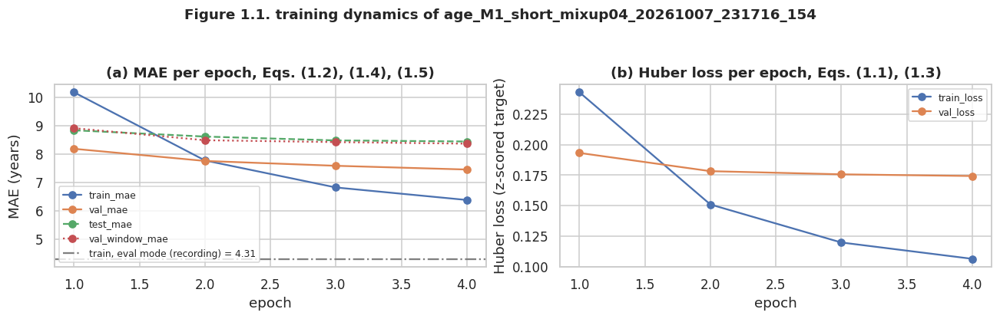

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ep = np.arange(1, len(log) + 1)
for c, ls in (("train_mae", "-"), ("val_mae", "-"), ("test_mae", "--"), ("val_window_mae", ":")):
    if c in log:
        ax[0].plot(ep, log[c], ls, marker="o", label=c)
train_eval_mae = regression_summary(train)["mae"]
ax[0].axhline(train_eval_mae, color="grey", ls="-.", label=f"train, eval mode (recording) = {train_eval_mae:.2f}")
ax[0].set(xlabel="epoch", ylabel="MAE (years)", title="MAE per epoch, Eqs. (1.2), (1.4), (1.5)")
ax[0].legend(fontsize=8)
for c in ("train_loss", "val_loss"):
    if c in log:
        ax[1].plot(ep, log[c], marker="o", label=c)
ax[1].set(xlabel="epoch", ylabel="Huber loss (z-scored target)", title="Huber loss per epoch, Eqs. (1.1), (1.3)")
ax[1].legend(fontsize=8)
panel_labels(ax)
figure_caption(fig, "1.1", "training dynamics of " + os.path.basename(BEST_RUN))
plt.tight_layout(); plt.show()

## 2. Error summary: mean vs. median, window vs. recording, cohort

Table 2.2 scores every split at two **levels** and for three **cohorts**:

* **window**: $\mathcal{S}$ = all scored windows; each 10 s window is a sample with prediction
  $\hat y_{r,w}$ and target $y_r$.
* **recording**: $\mathcal{S}$ = the recordings; the prediction is the mean over windows,
  $\hat y_r$ (Eq. (0.10)), the reported metric.
* **cohort**: `all`, or only TUAB's `normal` / `abnormal` recordings.

The train split is scored in eval mode on `TRAIN_WINDOWS_PER_RECORDING` windows per recording.
Every column is computed by `labram/eval/age_analysis.py::regression_summary` over the $n$ items
$i\in\mathcal{S}$ with error $e_i=\hat y_i-y_i$ (years); Table 2.1 maps each column to its
equation.

$$
\texttt{mae} = \frac{1}{n}\sum_{i\in\mathcal{S}}\lvert e_i\rvert
\tag{2.1}
$$

$$
\texttt{median\_ae} = \operatorname{median}_{i\in\mathcal{S}}\lvert e_i\rvert
\tag{2.2}
$$

$$
\texttt{p90\_ae} = Q_{0.90}\big(\{\lvert e_i\rvert\}_{i\in\mathcal{S}}\big)
\tag{2.3}
$$

$$
\texttt{rmse} = \sqrt{\frac{1}{n}\sum_{i\in\mathcal{S}} e_i^2}
\tag{2.4}
$$

$$
\texttt{r2} = R^2 = 1-\frac{\sum_i e_i^2}{\sum_i (y_i-\bar y)^2}
\tag{2.5}
$$

$$
\texttt{pearson\_r} = \frac{\sum_i(\hat y_i-\bar{\hat y})(y_i-\bar y)}{\sqrt{\sum_i(\hat y_i-\bar{\hat y})^2}\sqrt{\sum_i(y_i-\bar y)^2}}
\tag{2.6}
$$

$$
\texttt{mean\_err} = \bar e = \frac{1}{n}\sum_{i\in\mathcal{S}} e_i
\tag{2.7}
$$

$$
\texttt{median\_err} = \operatorname{median}_{i\in\mathcal{S}} e_i
\tag{2.8}
$$

$$
\texttt{bias\_slope} = b = \frac{\sum_i (y_i-\bar y)(e_i-\bar e)}{\sum_i (y_i-\bar y)^2} = a - 1,
\qquad \hat y_i \approx a\,y_i + c \ \text{(least squares)}
\tag{2.9}
$$

Here $Q_{0.90}$ is the 90th percentile (linear interpolation) and $\bar y$, $\bar{\hat y}$ are the
means over $\mathcal{S}$.

### Table 2.1. Column key for Table 2.2

| column | Eq. | what it tells |
|---|---|---|
| `n` | – | windows or recordings in the row |
| `mae` | (2.1) | average error size in years; the headline metric (recording level = `val_mae`, Eq. (1.5)) |
| `median_ae` | (2.2) | the typical error; less sensitive than `mae` to the large-error tail |
| `p90_ae` | (2.3) | 90% of the items are within this many years |
| `rmse` | (2.4) | weights large errors quadratically; `rmse` ≫ `mae` means a heavy tail |
| `r2` | (2.5) | share of the age variance explained; 0 = always predicting $\bar y$; can be negative. Not the square of `pearson_r` unless the fit is unbiased with slope 1 |
| `pearson_r` | (2.6) | linear association of prediction and age; ignores offset and scale |
| `mean_err` | (2.7) | signed bias: > 0 predicted too old on average |
| `median_err` | (2.8) | signed bias of the typical item |
| `bias_slope` | (2.9) | slope of the error against age; $b=-0.4$ means $\hat y\approx 0.6\,y + c$, so a 10-year age difference shows up as a 6-year prediction difference (regression to the mean, section 5) |

`bias_slope` is the same at window and recording level (each recording has one age and, on
val/test, the same number of windows). `mae`, `rmse` and `p90_ae` shrink from window to recording
level because pooling averages out window noise.

### Table 2.2. Error summary per level, split and cohort

Years; columns as in Table 2.1, Eqs. (2.1)–(2.9).

In [9]:
summary = summary_table({"window": win, "recording": rec})
display(numbered_table(summary.style.format(precision=2)
                       .background_gradient(subset=["mae", "median_ae"], cmap="Reds"),
                       "2.2", "error summary per level × split × cohort (years; Eqs. 2.1–2.9)"))

## 3. Error and loss distributions

All ages are in years, on the original scale. Figure 3.1 has six panels:

* (a) the distribution of **true vs. predicted age** per recording. The predicted distribution is
  visibly narrower, which is regression to the mean.
* (b) the **predicted age for each true-age decade**: the box spans the IQR, the line is the median
  and the whiskers reach 1.5 IQR. The green band marks where the prediction would equal the true
  age.
* (c) the empirical CDF of the recording absolute error,

$$
\hat F(a) = \frac{1}{n}\,\#\{\,r : \lvert e_r\rvert \le a\,\}
\tag{3.1}
$$

* (d) the recording $\lvert e_r\rvert$ by cohort.
* (e) and (f) the per-window **Huber loss** in eval mode, Eq. (0.5) on the unmixed window,
  $\ell_{r,w} = \ell_\delta\big((\hat y_{r,w}-y_r)/\sigma_y\big)$, with $\delta=1$. Panel (e) shows how
  much of the total loss sits in the worst windows. With the per-window losses sorted in decreasing
  order, $\ell_{(1)}\ge\ell_{(2)}\ge\dots\ge\ell_{(N)}$:

$$
\mathrm{share}(q) = \frac{\sum_{k=1}^{\lceil qN\rceil}\ell_{(k)}}{\sum_{k=1}^{N}\ell_{(k)}},
\qquad q\in[0,1]
\tag{3.2}
$$

Table 3.1 gives quantiles of the recording $\lvert e_r\rvert$ ($Q_p$ as in Eq. (2.3)).

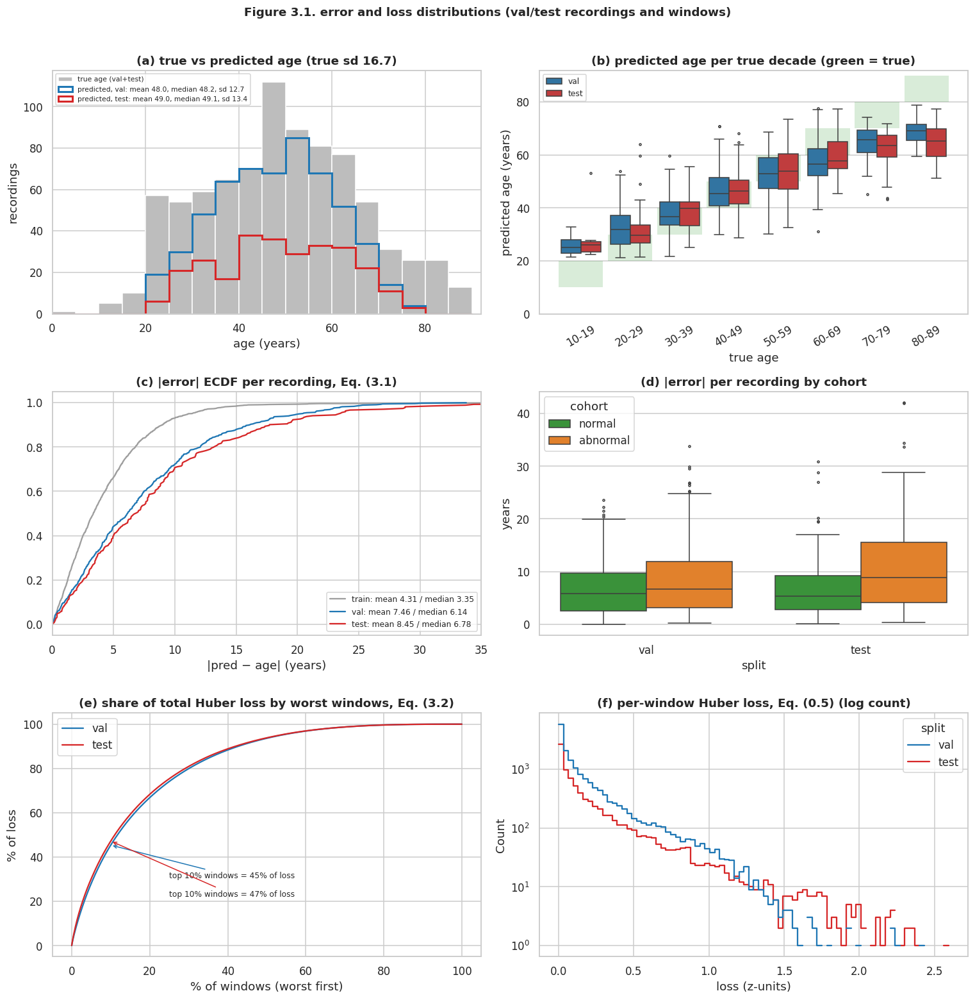

In [10]:
sigma = run.target_stats[1]
win["huber"] = np.where((win.err / sigma).abs() <= 1, 0.5 * (win.err / sigma) ** 2,
                        (win.err / sigma).abs() - 0.5)
fig, ax = plt.subplots(3, 2, figsize=(14, 14))
ev_rec = rec[rec.split != "train"]
age_bins = np.arange(0, 95, 5)
ax[0, 0].hist(ev_rec.age, bins=age_bins, color="#bdbdbd", label="true age (val+test)")
for split in ("val", "test"):
    d = ev_rec[ev_rec.split == split]
    ax[0, 0].hist(d.pred, bins=age_bins, histtype="step", lw=2, color=SPLIT_COLORS[split],
                  label=f"predicted, {split}: mean {d.pred.mean():.1f}, median {d.pred.median():.1f}, "
                        f"sd {d.pred.std():.1f}")
ax[0, 0].set(title=f"true vs predicted age (true sd {ev_rec.age.std():.1f})",
             xlabel="age (years)", ylabel="recordings", xlim=AGE_LIM)
ax[0, 0].legend(fontsize=7)
bx = ev_rec.assign(age_bin=assign_age_bin(ev_rec.age))
order = [l for l in age_bin_labels() if (bx.age_bin.astype(str) == l).sum() >= 3]
sns.boxplot(data=bx[bx.age_bin.astype(str).isin(order)], x="age_bin", y="pred", hue="split",
            order=order, palette=SPLIT_COLORS, ax=ax[0, 1], fliersize=2)
for k, lab in enumerate(order):
    lo, hi = (int(v) for v in lab.split("-"))
    ax[0, 1].fill_between([k - 0.45, k + 0.45], lo, hi + 1, color="green", alpha=0.15, lw=0)
ax[0, 1].set(title="predicted age per true decade (green = true)", xlabel="true age",
             ylabel="predicted age (years)", ylim=AGE_LIM)
ax[0, 1].tick_params(axis="x", rotation=30)
ax[0, 1].legend(fontsize=8, loc="upper left")
for split in ("train", "val", "test"):
    d = rec[rec.split == split].abs_err.sort_values()
    ax[1, 0].plot(d, np.linspace(0, 1, len(d)), color=SPLIT_COLORS[split],
                  label=f"{split}: mean {d.mean():.2f} / median {d.median():.2f}")
ax[1, 0].set(title="|error| ECDF per recording, Eq. (3.1)", xlabel="|pred − age| (years)", xlim=(0, 35))
ax[1, 0].legend(fontsize=8)

ev = win[win.split != "train"]
sns.boxplot(data=ev_rec, x="split", y="abs_err", hue="cohort",
            palette=COHORT_COLORS, ax=ax[1, 1], showfliers=True, fliersize=2)
ax[1, 1].set(title="|error| per recording by cohort", ylabel="years")
for split in ("val", "test"):
    h = ev[ev.split == split].huber.sort_values(ascending=False).to_numpy()
    share = np.cumsum(h) / h.sum()
    ax[2, 0].plot(np.linspace(0, 100, len(h)), share * 100, color=SPLIT_COLORS[split], label=split)
    top10 = share[int(0.1 * len(h))] * 100
    ax[2, 0].annotate(f"top 10% windows = {top10:.0f}% of loss", (10, top10),
                      xytext=(25, top10 - 15 - 10 * (split == "test")), fontsize=8,
                      arrowprops=dict(arrowstyle="->", color=SPLIT_COLORS[split]))
ax[2, 0].set(title="share of total Huber loss by worst windows, Eq. (3.2)", xlabel="% of windows (worst first)",
             ylabel="% of loss")
ax[2, 0].legend()
sns.histplot(data=ev, x="huber", hue="split", bins=80, log_scale=(False, True), element="step",
             fill=False, palette=SPLIT_COLORS, ax=ax[2, 1])
ax[2, 1].set(title="per-window Huber loss, Eq. (0.5) (log count)", xlabel="loss (z-units)")
panel_labels(ax)
figure_caption(fig, "3.1", "error and loss distributions (val/test recordings and windows)")
plt.tight_layout(); plt.show()

### Table 3.1. Quantiles of the recording absolute error

Mean and quantiles $Q_p$ (Eq. (2.3)) of $\lvert e_r\rvert$ in years, val and test.

In [11]:
q = (rec[rec.split != "train"].groupby("split").abs_err
     .describe(percentiles=[.5, .75, .9, .95]).drop(columns=["count", "std"]))
display(numbered_table(q.rename(columns=lambda c: f"|err| {c}"), "3.1",
                       "recording absolute error |e_r| (years): mean and quantiles"))

,|err| mean,|err| min,|err| 50%,|err| 75%,|err| 90%,|err| 95%,|err| max
split,,,,,,,
test,8.45,0.04,6.78,11.39,17.72,23.37,42.07
val,7.46,0.00,6.14,10.51,16.08,20.21,33.77


## 4. Per-sample view: windows inside a recording

How much do a recording's 30 window predictions disagree? Does the disagreement flag a bad
recording? Does median pooling beat mean pooling? Does the position in the recording matter?
TUAB sessions often contain hyperventilation and photic stimulation, and patients get drowsy as a
session goes on.

The within-recording spread is the sample std of the window predictions; median pooling replaces the
mean of Eq. (0.10) with the median; the window's position is its start time
$t_w = 10\,w/60$ minutes from the start of the EDF, with $w$ the window number in the file name:

$$
s_r = \sqrt{\frac{1}{W_r-1}\sum_{w=1}^{W_r}\left(\hat y_{r,w}-\hat y_r\right)^2}
\tag{4.1}
$$

$$
\hat y_r^{\,\mathrm{med}} = \operatorname{median}_{w}\ \hat y_{r,w},
\qquad
e_r^{\,\mathrm{med}} = \hat y_r^{\,\mathrm{med}} - y_r
\tag{4.2}
$$

**Figure 4.1.** (a) Histogram of $s_r$ (Eq. (4.1)). (b) $s_r$ against the recording $\lvert e_r\rvert$,
with Pearson $r$ (Eq. (2.6)). (c) Window MAE (Eq. (2.1)) and median AE (Eq. (2.2)) per minute of
recording; bins with at least 100 windows. (d) Recording $\lvert e_r\rvert$ under mean vs. median
pooling (Eq. (4.2)); points below the diagonal are better with the median.

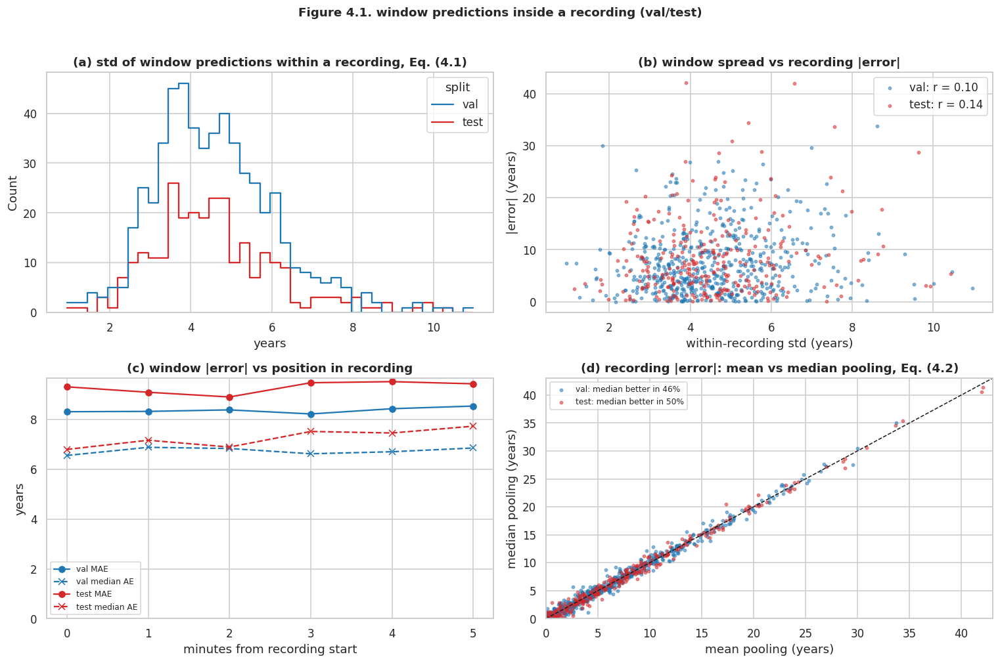

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
ax = ax.ravel()
ev_rec = rec[rec.split != "train"]
sns.histplot(data=ev_rec, x="pred_std", hue="split", bins=40, element="step", fill=False,
             palette=SPLIT_COLORS, ax=ax[0])
ax[0].set(title="std of window predictions within a recording, Eq. (4.1)", xlabel="years")
for split in ("val", "test"):
    d = ev_rec[ev_rec.split == split]
    r = np.corrcoef(d.pred_std, d.abs_err)[0, 1]
    ax[1].scatter(d.pred_std, d.abs_err, s=8, alpha=0.5, color=SPLIT_COLORS[split],
                  label=f"{split}: r = {r:.2f}")
ax[1].set(title="window spread vs recording |error|", xlabel="within-recording std (years)",
          ylabel="|error| (years)")
ax[1].legend()
ev = win[win.split != "train"].copy()
ev["t_min"] = ev.window * 10 / 60
ev["t_bin"] = pd.cut(ev.t_min, bins=np.arange(0, ev.t_min.max() + 2, 1.0))
pos = ev.groupby(["split", "t_bin"], observed=True).agg(mae=("abs_err", "mean"),
                                                        median_ae=("abs_err", "median"),
                                                        n=("err", "size")).reset_index()
pos["t"] = pos.t_bin.apply(lambda iv: iv.left)
for split in ("val", "test"):
    d = pos[(pos.split == split) & (pos.n >= 100)]
    ax[2].plot(d.t, d.mae, marker="o", color=SPLIT_COLORS[split], label=f"{split} MAE")
    ax[2].plot(d.t, d.median_ae, marker="x", ls="--", color=SPLIT_COLORS[split],
               label=f"{split} median AE")
ax[2].set(title="window |error| vs position in recording", xlabel="minutes from recording start",
          ylabel="years", ylim=(0, None))
ax[2].legend(fontsize=8)
for split in ("val", "test"):
    d = ev_rec[ev_rec.split == split]
    better = (d.abs_err_median_pool < d.abs_err).mean()
    ax[3].scatter(d.abs_err, d.abs_err_median_pool, s=8, alpha=0.5, color=SPLIT_COLORS[split],
                  label=f"{split}: median better in {better:.0%}")
lim = (0, float(ev_rec[["abs_err", "abs_err_median_pool"]].max().max()) + 1)
ax[3].plot(lim, lim, color="k", lw=1, ls="--")
ax[3].set(title="recording |error|: mean vs median pooling, Eq. (4.2)", xlabel="mean pooling (years)",
          ylabel="median pooling (years)", xlim=lim, ylim=lim)
ax[3].legend(fontsize=8)
panel_labels(ax)
figure_caption(fig, "4.1", "window predictions inside a recording (val/test)")
plt.tight_layout(); plt.show()

### Table 4.1. MAE by pooling

Window MAE (Eq. (2.1)), recording MAE with mean (Eq. (0.10)) and median (Eq. (4.2)) pooling, and the mean within-recording spread $s_r$ (Eq. (4.1)), per split.

In [13]:
pool = pd.DataFrame({
    "window MAE": win.groupby("split").abs_err.mean(),
    "recording MAE (mean pool)": rec.groupby("split").abs_err.mean(),
    "recording MAE (median pool)": rec.groupby("split").abs_err_median_pool.mean(),
    "mean within-rec std": rec.groupby("split").pred_std.mean(),
}).loc[["train", "val", "test"]]
display(numbered_table(pool, "4.1", "MAE (years) by pooling: window (Eq. 2.1), recording mean (Eq. 0.10) and median (Eq. 4.2) pooling, and mean s_r (Eq. 4.1)"))

,window MAE,recording MAE (mean pool),recording MAE (median pool),mean within-rec std
split,,,,
train,5.49,4.31,4.24,4.36
val,8.37,7.46,7.53,4.58
test,9.28,8.45,8.43,4.58


## 5. Regression to the mean, against the train sampling density

The core failure. Young subjects are predicted older and old subjects younger than they are.
Per split, a least-squares line of prediction on age,

$$
\hat y_r \approx a\,y_r + c,
\qquad
a = 1 + b
\tag{5.1}
$$

has slope $a<1$, with $b$ the `bias_slope` of Eq. (2.9). Each true-age decade $d$ (bins $[0,10)$,
$[10,20)$, …, $[80,90)$) is summarised over its recordings $r\in d$, and set against the number of
**train windows** in the decade:

$$
\overline{\hat y}_d = \frac{1}{n_d}\sum_{r\in d}\hat y_r,
\qquad
\mathrm{MAE}_d = \frac{1}{n_d}\sum_{r\in d}\lvert e_r\rvert,
\qquad
N^{\text{train}}_d = \#\{\text{train windows } i: y_i\in d\}
\tag{5.2}
$$

**Figure 5.1.** (a) Train windows per year of age: the model sees ages 40–60 far more often than
children or people over 80. (b)–(d) Predicted vs. true age per recording for train (eval mode), val
and test, coloured by cohort, with the fit of Eq. (5.1). (e) Decade MAE (Eq. (5.2)) against the
decade's train density $N^{\text{train}}_d$. If the bias simply followed sampling density, the
worst-served decades would be the rarest ones. (f) Median predicted age with its IQR per true-age
decade; the further it sits from the diagonal, the stronger the pull toward the train mean
$\mu_y$ (~49 y).

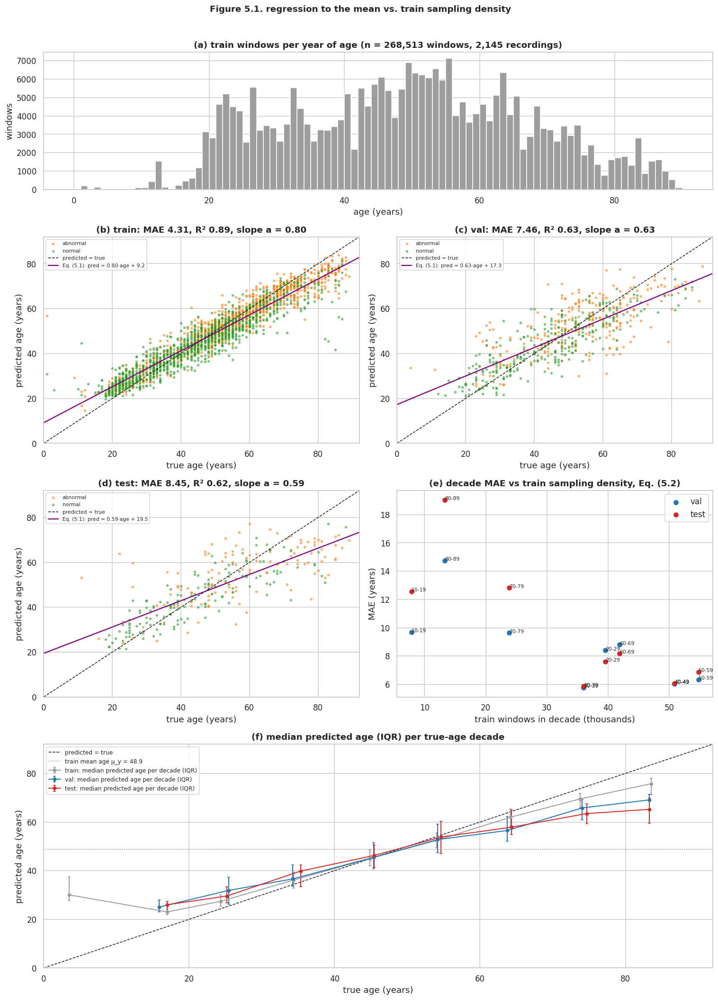

In [14]:
fig = plt.figure(figsize=(14, 19))
gs = fig.add_gridspec(4, 2, height_ratios=[0.8, 1.2, 1.2, 1.3])
ax0 = fig.add_subplot(gs[0, :])
train_ages = np.asarray([a for a in run.split("train").ages()])
ax0.hist(train_ages, bins=np.arange(0, 91, 1), color="#9e9e9e")
ax0.set(title=f"train windows per year of age (n = {len(train_ages):,} windows, "
              f"{len(train):,} recordings)", xlabel="age (years)", ylabel="windows")
axes = [ax0]
for cell, split in zip((gs[1, 0], gs[1, 1], gs[2, 0]), ("train", "val", "test")):
    d = rec[rec.split == split]
    a = fig.add_subplot(cell)
    axes.append(a)
    for cohort, c in d.groupby("cohort"):
        a.scatter(c.age, c.pred, s=7, alpha=0.5, color=COHORT_COLORS[cohort], label=cohort)
    identity(a)
    slope, icpt = np.polyfit(d.age, d.pred, 1)
    a.plot(AGE_LIM, np.polyval([slope, icpt], AGE_LIM), color="purple", lw=1.5,
           label=f"Eq. (5.1): pred = {slope:.2f}·age + {icpt:.1f}")
    s = regression_summary(d)
    a.set(title=f"{split}: MAE {s['mae']:.2f}, R² {s['r2']:.2f}, slope a = {slope:.2f}",
          xlabel="true age (years)", ylabel="predicted age (years)")
    a.legend(fontsize=7, loc="upper left")
bins = error_by_age_bin(rec, by=["split"]).reset_index()
labels = age_bin_labels()
a = fig.add_subplot(gs[2, 1])
axes.append(a)
dens = pd.Series(assign_age_bin(pd.Series(train_ages))).value_counts().reindex(labels)
for split in ("val", "test"):
    d = bins[bins.split == split].set_index("age_bin").reindex(labels)
    ok = d.n >= 5
    a.scatter(dens[ok] / 1000, d.mae[ok], color=SPLIT_COLORS[split], label=split)
    for lab in np.array(labels)[ok.to_numpy()]:
        a.annotate(lab, (dens[lab] / 1000, d.mae[lab]), fontsize=7)
a.set(xlabel="train windows in decade (thousands)", ylabel="MAE (years)",
      title="decade MAE vs train sampling density, Eq. (5.2)")
a.legend()
a = fig.add_subplot(gs[3, :])
axes.append(a)
identity(a)
a.axhline(run.target_stats[0], color="grey", ls=":", lw=1, label=f"train mean age μ_y = {run.target_stats[0]:.1f}")
for split in ("train", "val", "test"):
    plot_pred_by_bin(a, rec[rec.split == split], f"{split}: median predicted age per decade (IQR)",
                     SPLIT_COLORS[split], min_n=3)
a.set(title="median predicted age (IQR) per true-age decade", xlabel="true age (years)",
      ylabel="predicted age (years)")
a.legend(fontsize=8, loc="upper left")
panel_labels(axes)
figure_caption(fig, "5.1", "regression to the mean vs. train sampling density")
plt.tight_layout(); plt.show()

### Table 5.1. Error per true-age decade

Per decade and split: `n` = $n_d$; `age_mean`; `pred_mean` = $\overline{\hat y}_d$;
`pred_median`, `pred_q25`, `pred_q75` = the median and quartiles of $\hat y_r$ in the decade; `mae` =
$\mathrm{MAE}_d$; `median_ae` = Eq. (2.2) within the decade.

In [15]:
display(numbered_table(error_by_age_bin(rec[rec.split != "train"], by=["split"])
        [["n", "age_mean", "pred_mean", "pred_median", "pred_q25", "pred_q75", "mae", "median_ae"]],
        "5.1", "per true-age decade, val and test recordings (years; Eq. 5.2)"))

## 6. Post-hoc bias correction (fit on val, apply to test)

Each correction is fitted on the validation recordings (all, or normal only, which is the usual
"healthy controls" choice) and applied to test. Two least-squares fits on val
(`fit_bias_correction`):

$$
\hat y \approx a\,y + c
\qquad\text{and}\qquad
y \approx \alpha\,\hat y + \beta
\tag{6.1}
$$

The corrections (`apply_bias_correction`):

$$
\textbf{cole:}\quad \hat y' = \frac{\hat y - c}{a}
\tag{6.2}
$$

$$
\textbf{recalibrate:}\quad \hat y' = \alpha\,\hat y + \beta
\tag{6.3}
$$

$$
\textbf{age\_level:}\quad \hat y' = \hat y - (a-1)\,y - c
\tag{6.4}
$$

* **cole** inverts the fit of Eq. (6.1). It is deployable, since it uses only the prediction, and it
  sets the bias slope (Eq. (2.9)) to about 0.
* **recalibrate** is the MSE-optimal linear map from prediction to age. It is deployable, and with
  $\alpha\approx 1$ it changes little.
* **age_level** subtracts the age-dependent bias using the **true age** $y$. This is the standard
  brain-age-*gap* correction. It is not an age estimate, and its MAE cannot be compared with the others.

**Figure 6.1.** Test, per true-age decade
(Eq. (5.2)): (a) mean corrected prediction; (b) MAE after correction.

### Table 6.1. Test metrics after each bias correction

Test metrics after each correction: MAE (Eq. (2.1)), median AE (Eq. (2.2)), bias
slope (Eq. (2.9)), and MAE per cohort (Eq. (1.7)).

In [16]:
rows, curves = [], {}
for fit_name, fit in (("val (all)", val), ("val (normal)", val[val.cohort == "normal"])):
    params = fit_bias_correction(fit.pred, fit.age)
    for method in CORRECTIONS:
        p = apply_bias_correction(test.pred, params, method, test.age)
        d = test.assign(pred=p)
        s = regression_summary(d)
        rows.append({"fit on": fit_name, "method": method, "deployable": method != "age_level",
                     "test MAE": s["mae"], "median AE": s["median_ae"], "bias slope": s["bias_slope"],
                     "normal MAE": regression_summary(d[d.cohort == "normal"])["mae"],
                     "abnormal MAE": regression_summary(d[d.cohort == "abnormal"])["mae"]})
        if fit_name == "val (all)":
            curves[method] = error_by_age_bin(add_errors(d.copy()))
    if fit_name == "val (all)":
        print("fit on val: pred = %.3f * age + %.2f   |   age ~= %.3f * pred + %.2f"
              % (params["slope"], params["intercept"], params["recal_a"], params["recal_b"]))
display(numbered_table(pd.DataFrame(rows).set_index(["fit on", "method"]), "6.1",
                       "test recordings after bias correction (years; Eqs. 6.2–6.4)"))

fit on val: pred = 0.634 * age + 17.29   |   age ~= 0.999 * pred + 0.46


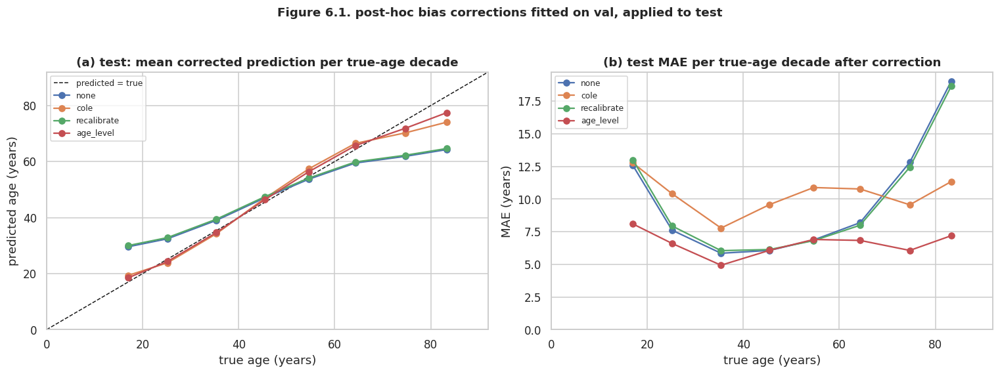

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
identity(ax[0])
for method, c in curves.items():
    c = c[c.n >= 3]
    ax[0].plot(c.age_mean, c.pred_mean, marker="o", label=method)
    ax[1].plot(c.age_mean, c.mae, marker="o", label=method)
ax[0].set(title="test: mean corrected prediction per true-age decade", xlabel="true age (years)",
          ylabel="predicted age (years)")
ax[1].set(title="test MAE per true-age decade after correction", xlabel="true age (years)",
          ylabel="MAE (years)", xlim=AGE_LIM, ylim=(0, None))
for a in ax: a.legend(fontsize=8)
panel_labels(ax)
figure_caption(fig, "6.1", "post-hoc bias corrections fitted on val, applied to test")
plt.tight_layout(); plt.show()

## 7. Normal vs. abnormal, and the spectral correlates of the error

The abnormal recordings are older and their EEG is slower: more delta/theta, less alpha and a lower
peak alpha frequency (PAF). EEG slowing is also a classic marker of ageing. The question is whether
the model mistakes pathological slowing for age.

Features per recording (`recording_spectral_features`) are computed after CAR (Eq. (0.1), without
the /100), over up to 6 of its scored windows. For channel $c$ of window $w$, $P_{c,w}(f)$ is the
Welch PSD (2 s Hann segments, 50% overlap, 0.5 Hz resolution, µV²/Hz). For a band
$\mathcal{B}\in\{\delta\,[1,4),\ \theta\,[4,8),\ \alpha\,[8,13),\ \beta\,[13,30),\ \gamma\,[30,45)\}$ Hz:

$$
\texttt{rel\_}\mathcal{B} = \frac{1}{\lvert w\rvert\,C}\sum_{w}\sum_{c}\frac{\sum_{f\in\mathcal{B}}P_{c,w}(f)}{\sum_{1\le f<45}P_{c,w}(f)}
\tag{7.1}
$$

$$
\texttt{paf} = \operatorname*{arg\,max}_{7\le f\le 13}\ \frac{1}{\lvert\mathcal{P}\rvert}\sum_{c\in\mathcal{P}}\frac{1}{\lvert w\rvert}\sum_{w}P_{c,w}(f),
\qquad \mathcal{P}=\{\mathrm{O1,O2,P3,P4,Pz,T5,T6}\}
\tag{7.2}
$$

$$
\texttt{theta\_alpha} = \frac{\texttt{rel\_theta}}{\texttt{rel\_alpha}},
\qquad
\texttt{amp\_uv} = \frac{1}{\lvert w\rvert\,C}\sum_{w}\sum_{c}\operatorname{std}_t\big(x_{c,t}\big)
\tag{7.3}
$$

A PAF of 7 Hz sits at the edge of the search band and means *no alpha peak*, which is typical of
diffusely slowed abnormal EEG. The error is **age-detrended** (its least-squares line in age over the
val+test recordings is removed), so that regression to the mean does not masquerade as a spectral
effect. Associations use Spearman's rank correlation, i.e. Eq. (2.6) applied to the ranks:

$$
\tilde e_r = e_r - (k\,y_r + m),
\qquad (k, m) = \operatorname*{arg\,min}_{k,m}\sum_r\big(e_r - k\,y_r - m\big)^2
\tag{7.4}
$$

$$
\rho(u, v) = \operatorname{pearson}\big(\operatorname{rank}(u),\ \operatorname{rank}(v)\big)
\tag{7.5}
$$

**Figure 7.1.** (a) True-age
distribution per cohort. (b) Median predicted age (IQR) per decade by cohort. (c) The same by PAF
group. (d) True vs. predicted age coloured by PAF. 

In [18]:
fpath = os.path.join(BEST_RUN, "analysis", "spectral_features.parquet")
if os.path.exists(fpath):
    feats = pd.read_parquet(fpath)
else:
    feats = pd.concat([recording_spectral_features(run.split(s), win[win.split == s], run.ch_names)
                       for s in ("val", "test")], ignore_index=True)
    feats.to_parquet(fpath)
ev_rec = rec[rec.split != "train"].merge(feats, on=["split", "recording"])
ev_rec["err_detrended"] = ev_rec.err - np.polyval(np.polyfit(ev_rec.age, ev_rec.err, 1), ev_rec.age)
FEATS = ["paf", "theta_alpha", "rel_delta", "rel_theta", "rel_alpha", "rel_beta", "amp_uv"]

### Table 7.1. Spectral features by cohort

Median per recording and cohort of age, $\lvert e_r\rvert$, $e_r$ and the features of
Eqs. (7.1)–(7.3).

In [19]:
display(numbered_table(ev_rec.groupby("cohort")[["age", "abs_err", "err"] + FEATS].median()
                       .T.rename_axis("median per recording"), "7.1",
                       "median per recording by cohort (val + test; Eqs. 7.1–7.3)"))

cohort,abnormal,normal
median per recording,,
age,55.00,44.00
abs_err,7.42,5.44
err,-0.77,0.06
paf,7.50,10.00
theta_alpha,1.40,0.47
rel_delta,0.53,0.37
rel_theta,0.16,0.11
rel_alpha,0.11,0.24
rel_beta,0.10,0.16


### Table 7.2. Spectral correlates of age and of the detrended error

Spearman $\rho$ (Eq. (7.5)) of each feature with age and with the
detrended error $\tilde e_r$ (Eq. (7.4)), overall and within each cohort.

In [20]:
corr = pd.DataFrame({
    "ρ(feature, age)": ev_rec[FEATS].corrwith(ev_rec.age, method="spearman"),
    "ρ(feature, age-detrended error)": ev_rec[FEATS].corrwith(ev_rec.err_detrended, method="spearman"),
    "ρ within normal": ev_rec[ev_rec.cohort == "normal"][FEATS].corrwith(
        ev_rec[ev_rec.cohort == "normal"].err_detrended, method="spearman"),
    "ρ within abnormal": ev_rec[ev_rec.cohort == "abnormal"][FEATS].corrwith(
        ev_rec[ev_rec.cohort == "abnormal"].err_detrended, method="spearman"),
})
display(numbered_table(corr.style.format(precision=2).background_gradient(cmap="RdBu_r", vmin=-0.4, vmax=0.4),
                       "7.2", "Spearman ρ (Eq. 7.5) of spectral features with age and with the age-detrended error (Eq. 7.4)"))

,"ρ(feature, age)","ρ(feature, age-detrended error)",ρ within normal,ρ within abnormal
paf,-0.27,-0.22,-0.13,-0.15
theta_alpha,0.17,0.17,-0.02,0.15
rel_delta,0.06,0.09,-0.17,0.15
rel_theta,0.05,0.06,-0.08,0.05
rel_alpha,-0.15,-0.16,-0.00,-0.13
rel_beta,-0.04,-0.07,0.23,-0.17
amp_uv,-0.05,-0.05,-0.15,-0.02


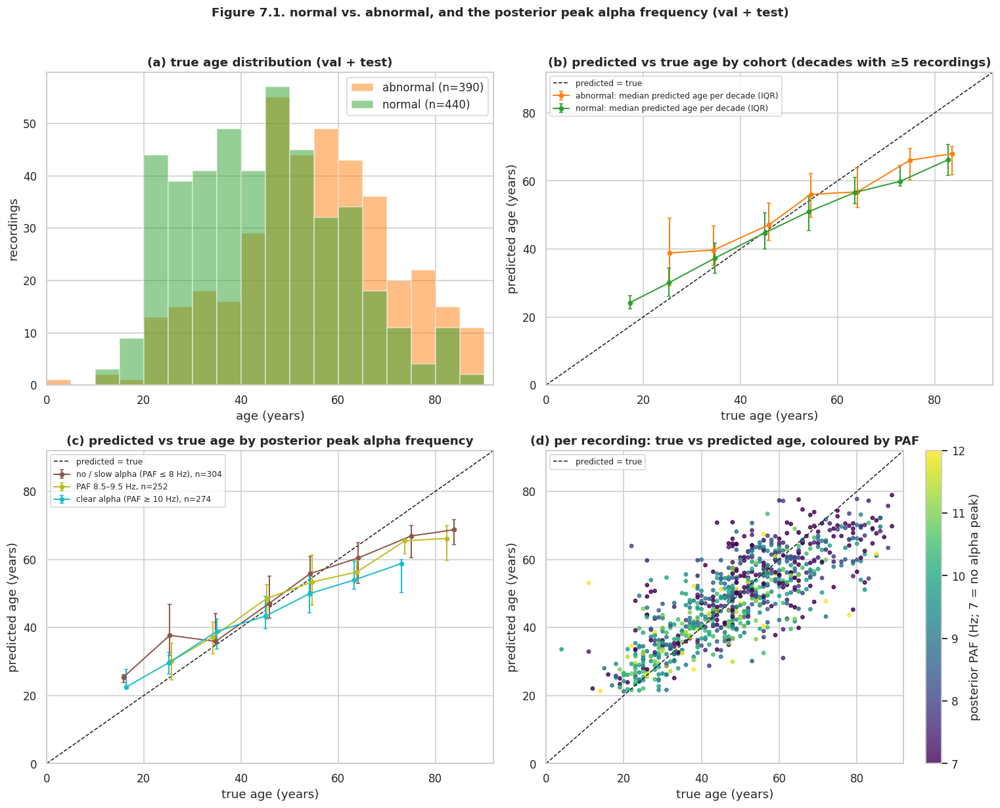

In [21]:
fig, ax = plt.subplots(2, 2, figsize=(14, 11))
for cohort, d in ev_rec.groupby("cohort"):
    ax[0, 0].hist(d.age, bins=np.arange(0, 95, 5), alpha=0.5, color=COHORT_COLORS[cohort],
                  label=f"{cohort} (n={len(d)})")
ax[0, 0].set(title="true age distribution (val + test)", xlabel="age (years)", ylabel="recordings",
             xlim=AGE_LIM)
ax[0, 0].legend()
identity(ax[0, 1])
for cohort, d in ev_rec.groupby("cohort"):
    plot_pred_by_bin(ax[0, 1], d, f"{cohort}: median predicted age per decade (IQR)", COHORT_COLORS[cohort])
ax[0, 1].set(title="predicted vs true age by cohort (decades with ≥5 recordings)")
ax[0, 1].legend(fontsize=8, loc="upper left")
paf_groups = {"no / slow alpha (PAF ≤ 8 Hz)": (ev_rec.paf <= 8.0, "#8c564b"),
              "PAF 8.5–9.5 Hz": ((ev_rec.paf > 8.0) & (ev_rec.paf < 10.0), "#bcbd22"),
              "clear alpha (PAF ≥ 10 Hz)": (ev_rec.paf >= 10.0, "#17becf")}
identity(ax[1, 0])
for name, (mask, color) in paf_groups.items():
    plot_pred_by_bin(ax[1, 0], ev_rec[mask], f"{name}, n={int(mask.sum())}", color)
ax[1, 0].set(title="predicted vs true age by posterior peak alpha frequency")
ax[1, 0].legend(fontsize=8, loc="upper left")
sc = ax[1, 1].scatter(ev_rec.age, ev_rec.pred, c=ev_rec.paf.clip(7, 12), cmap="viridis", s=12, alpha=0.8)
identity(ax[1, 1])
plt.colorbar(sc, ax=ax[1, 1], label="posterior PAF (Hz; 7 = no alpha peak)")
ax[1, 1].set(title="per recording: true vs predicted age, coloured by PAF")
ax[1, 1].legend(fontsize=8, loc="upper left")
panel_labels(ax)
figure_caption(fig, "7.1", "normal vs. abnormal, and the posterior peak alpha frequency (val + test)")
plt.tight_layout(); plt.show()

### Table 7.3. Recordings by posterior PAF group

Per PAF group: count, abnormal
share, mean true and predicted age, median $\tilde e_r$ and MAE.

In [22]:
display(numbered_table(ev_rec.assign(paf_group=pd.cut(ev_rec.paf, [0, 8.0, 9.75, 99],
                                       labels=["≤ 8 Hz", "8.5–9.5 Hz", "≥ 10 Hz"]))
        .groupby("paf_group", observed=True)
        .agg(n=("age", "size"), abnormal_share=("cohort", lambda c: (c == "abnormal").mean()),
             true_age=("age", "mean"), predicted_age=("pred", "mean"),
             age_detrended_error=("err_detrended", "median"), mae=("abs_err", "mean")), "7.3",
                       "recordings by posterior PAF group (Eq. 7.2)"))

,n,abnormal_share,true_age,predicted_age,age_detrended_error,mae
paf_group,,,,,,
≤ 8 Hz,304,0.80,54.51,53.69,1.66,8.77
8.5–9.5 Hz,252,0.38,48.23,47.52,-0.35,7.60
≥ 10 Hz,274,0.19,43.77,43.11,-2.46,6.85


### Average spectra of over- vs. under-predicted recordings, age-matched

Recordings in the top and bottom quintiles of the age-detrended error $\tilde e_r$ (Eq. (7.4)).
Each quintile is compared within the 40–69 age range, so that the groups have similar ages.

**Figure 7.2.** (a) Mean posterior log-PSD, $\log_{10}$ of the posterior-channel average of
$P_{c,w}(f)$ over 6 windows per recording, with the IQR across recordings. (b) Histogram of the
posterior PAF (Eq. (7.2)) per group.

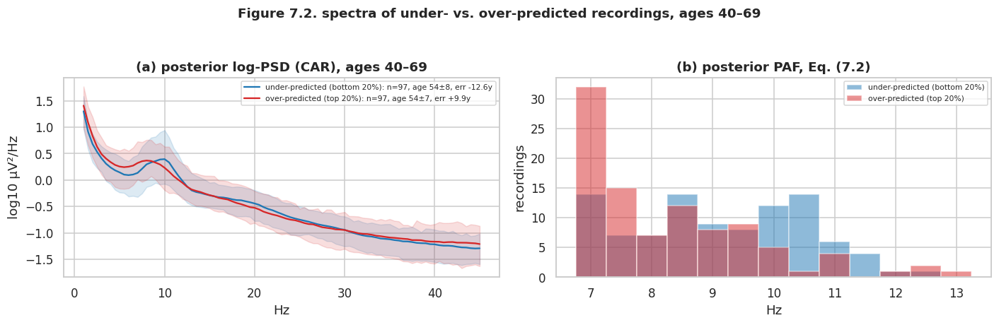

under-predicted (bottom 20%)     abnormal share 43%, median PAF 9.0 Hz, median theta/alpha 0.73
over-predicted (top 20%)         abnormal share 72%, median PAF 8.0 Hz, median theta/alpha 1.25


In [23]:
mid = ev_rec[(ev_rec.age >= 40) & (ev_rec.age < 70)]
lo, hi = mid.err_detrended.quantile([0.2, 0.8])
groups = {"under-predicted (bottom 20%)": mid[mid.err_detrended <= lo],
          "over-predicted (top 20%)": mid[mid.err_detrended >= hi]}
post = [i for i, c in enumerate(run.ch_names) if c.upper() in POSTERIOR]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for (name, g), color in zip(groups.items(), ("#1f77b4", "#d62728")):
    psds = []
    for _, r in g.iterrows():
        idx = win[(win.split == r.split) & (win.recording == r.recording)].idx.to_numpy()[:6]
        ds = run.split(r.split)
        x = np.stack([common_average_reference(load_window(ds, i)) for i in idx])
        _, freqs, psd = band_powers(x)
        psds.append(psd.mean(0)[post].mean(0))
    psds = np.log10(np.stack(psds))
    keep = (freqs >= 1) & (freqs <= 45)
    ax[0].plot(freqs[keep], psds.mean(0)[keep], color=color,
               label=f"{name}: n={len(g)}, age {g.age.mean():.0f}±{g.age.std():.0f}, "
                     f"err {g.err.mean():+.1f}y")
    ax[0].fill_between(freqs[keep], *np.percentile(psds, [25, 75], axis=0)[:, keep], color=color, alpha=0.15)
    ax[1].hist(g.paf, bins=np.arange(6.75, 13.5, 0.5), alpha=0.5, color=color, label=name)
ax[0].set(title="posterior log-PSD (CAR), ages 40–69", xlabel="Hz", ylabel="log10 µV²/Hz")
ax[0].legend(fontsize=7)
ax[1].set(title="posterior PAF, Eq. (7.2)", xlabel="Hz", ylabel="recordings")
ax[1].legend(fontsize=7)
panel_labels(ax)
figure_caption(fig, "7.2", "spectra of under- vs. over-predicted recordings, ages 40–69")
plt.tight_layout(); plt.show()
for name, g in groups.items():
    print(f"{name:32s} abnormal share {np.mean(g.cohort == 'abnormal'):.0%}, median PAF {g.paf.median():.1f} Hz, "
          f"median theta/alpha {g.theta_alpha.median():.2f}")

## 8. Real EEG: accurate vs. too young vs. too old, at the same true age

For each age in `COMPARE_AGES` (Parameters), three val/test recordings of about that true age
(±3 y): the one predicted **most accurately**, the one predicted **youngest** (under-predicted)
and the one predicted **oldest** (over-predicted). The EEG is real: one 10 s window per recording
(the window whose prediction is closest to the recording's mean), common-average referenced as the
model sees it, 19 standard 10-20 channels, and the **same µV scale** in all three panels. The
figure's lower panels hold the per-window predictions, the posterior spectra and the relative band
powers.

**Figures 8.1–8.4** (one per age in `COMPARE_AGES`). Panels (a)–(c) show the EEG of the accurate,
under- and over-predicted recordings, (d) the per-window predictions across each recording, (e) the
posterior spectrum and (f) the relative band power (Eq. (7.1)).

Change `COMPARE_AGES`, or call `ex.compare_at_age(age, tol=3, cohort="normal", split="test")`
yourself.

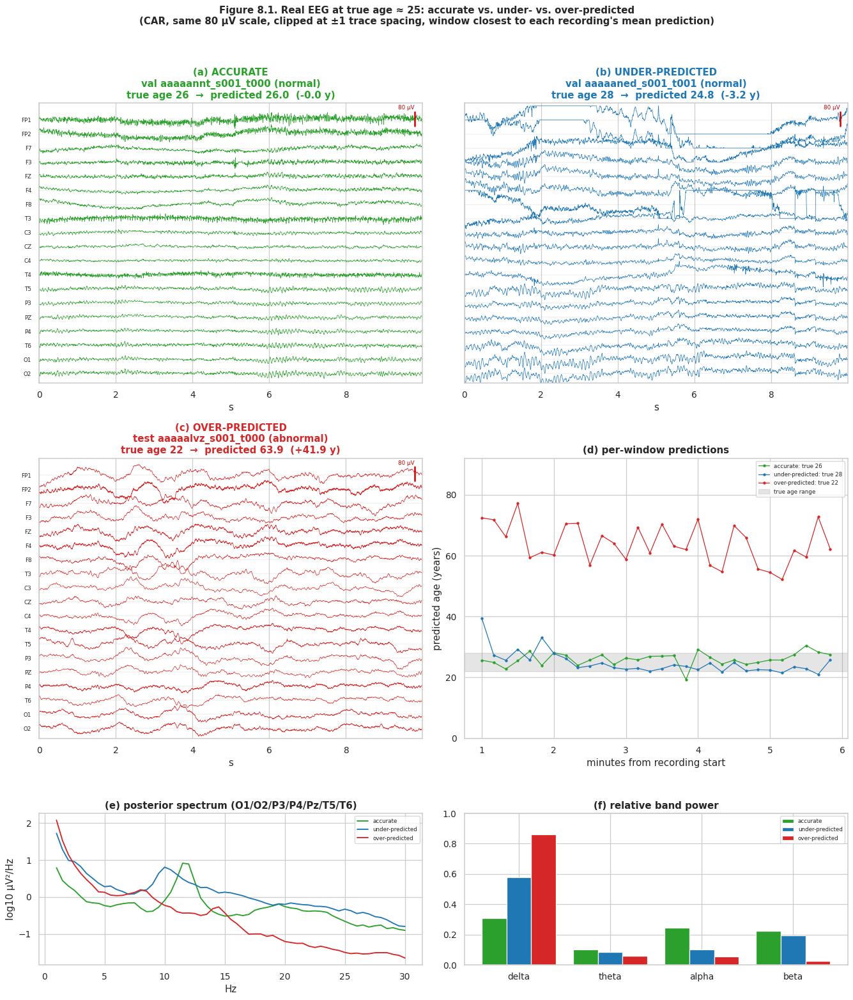

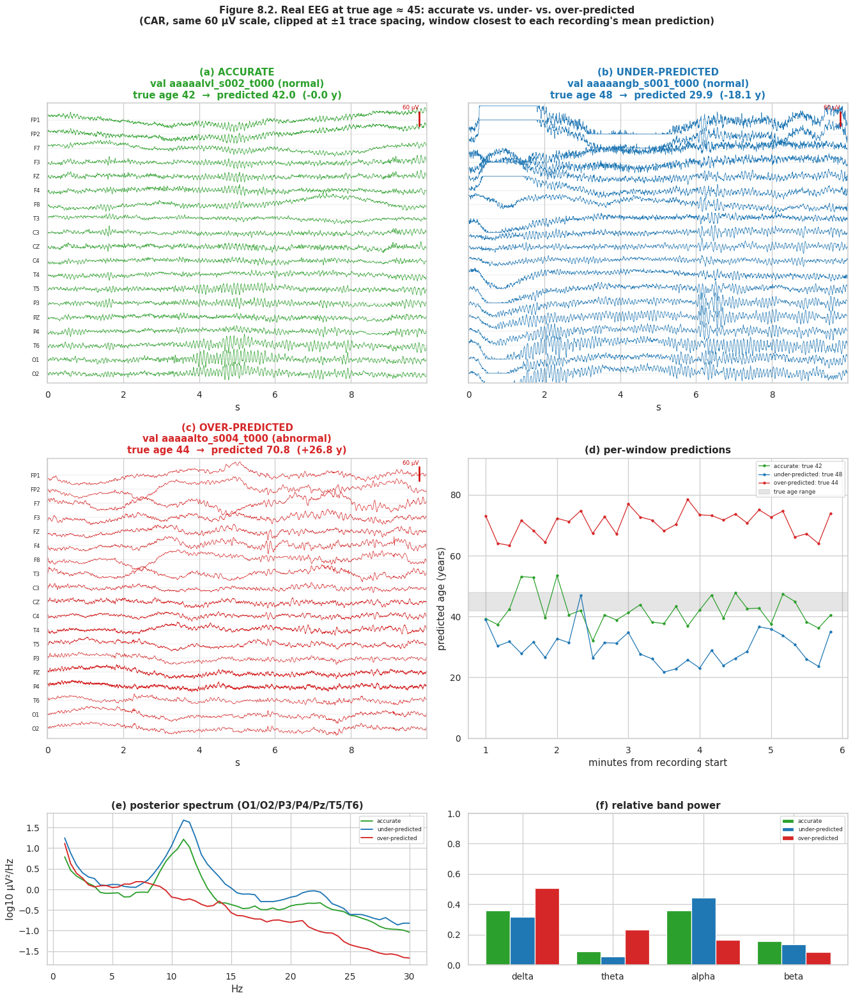

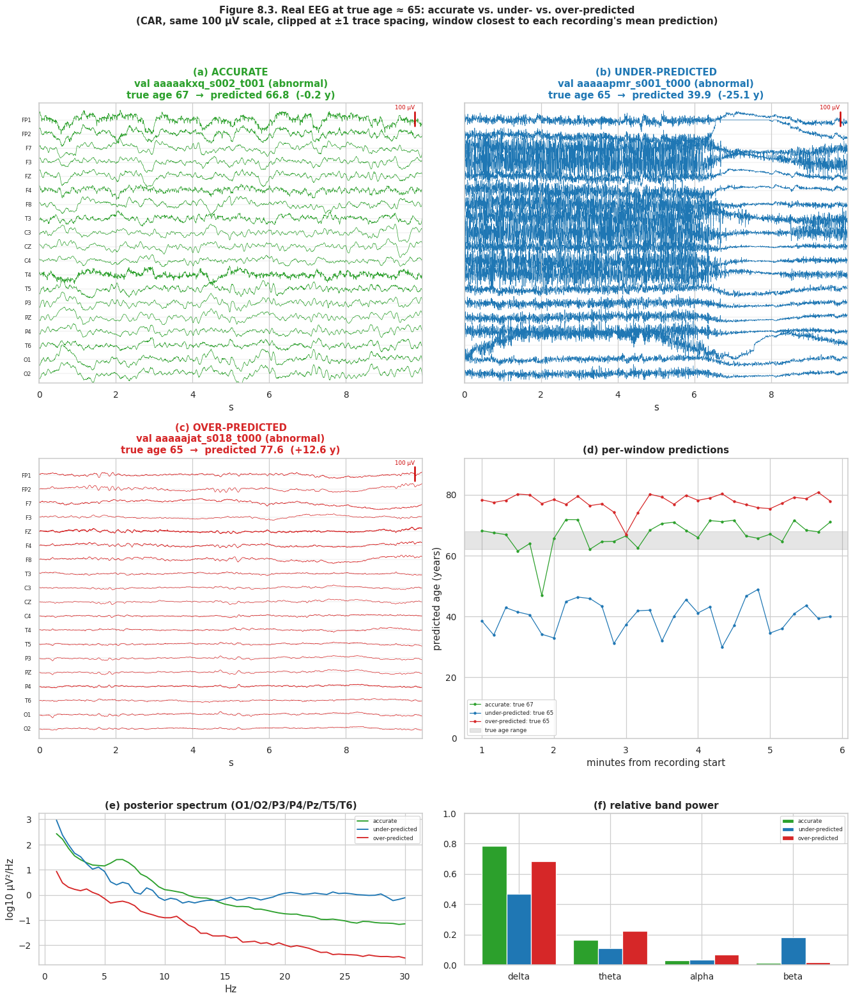

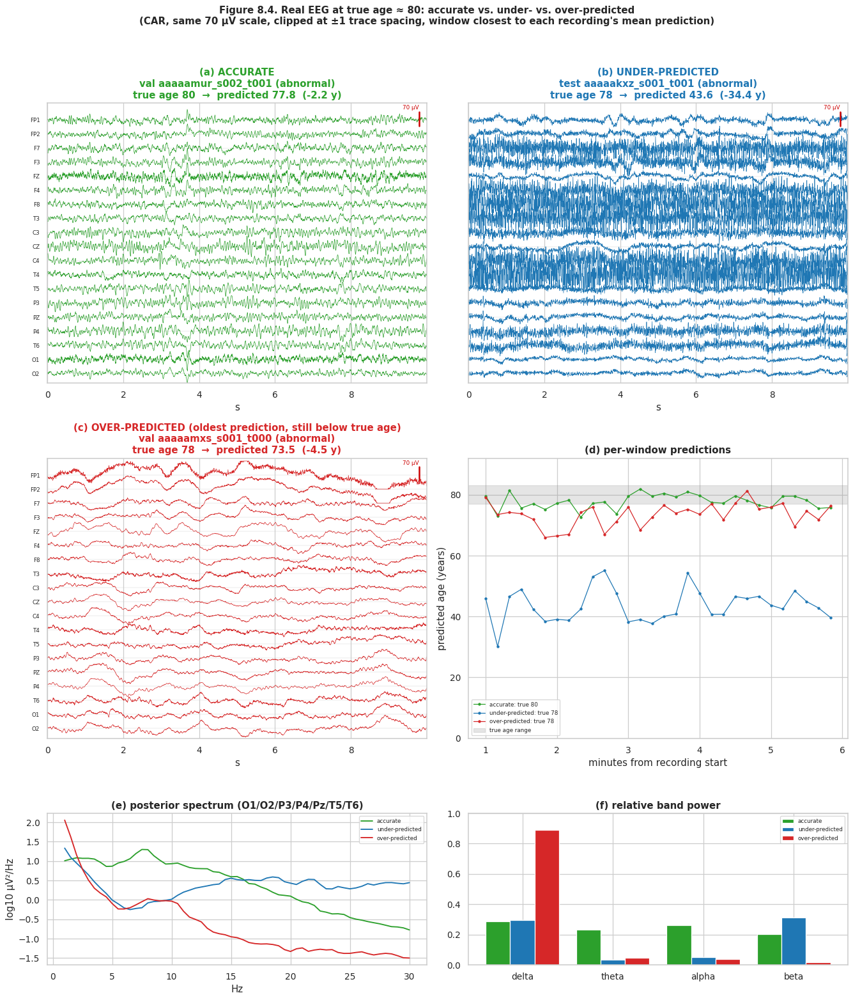

In [24]:
ex = AgeExplorer(run, win, rec, feats)
for k, age in enumerate(COMPARE_AGES):
    fig = ex.compare_at_age(age, number=f"8.{k + 1}")
    plt.show()

**What Figures 8.1–8.4 show (M1, as executed).** At the same true age the three outcomes look
different on the screen:

* **Too old** (red): slow EEG. Delta/theta dominate (50–89% delta), with a low or absent posterior
  alpha peak and little beta. Examples: a 22-year-old predicted 64, and a 44-year-old predicted 71
  (both abnormal, diffuse slowing).
* **Too young** (blue): *fast* EEG, of two kinds. At 45 it is a normal recording with a strong,
  high-frequency alpha rhythm (48 → 30). At 65 and 80 it is heavy high-frequency **muscle (EMG)
  artifact** across most channels, with beta at 17–31% of the power (65 → 40, 78 → 44). The model
  reads both as a "young" spectrum. Artifact-contaminated recordings are a concrete source of the largest
  under-predictions. However, re-pooling with EMG-heavy windows dropped or down-weighted
  (`scripts/age_artifact_pooling.py`; 30–45 Hz relative power per window) does **not** lower the
  MAE: on val the best setting for M1 is no rejection, and on test no setting moves the MAE by
  more than about 0.1 y. The artifact runs through the whole recording, so robust *inputs*
  (artifact-aware training) are the remaining lever, not pooling.
* **Accurate** (green): an age-typical background, e.g. a clear ~11 Hz alpha at 26 and 42.
* At 80, regression to the mean is visible directly: even the *oldest* prediction near 80 is below
  the true age (78 → 73.5). At 25, the *youngest* prediction is only 3 years too young (28 → 25),
  because nearly every young recording is pulled upward.

The per-window traces show that these are consistent offsets across the whole recording, not a few
bad windows.

### 8b. The extreme cases

The two most accurate, most over-predicted and most under-predicted recordings in val and test
(any age), listed in Table 8.1. **Figures 8.5 onward**, one per row of Table 8.1 in that order,
each show (a) the recording's most representative window, (b) all 30 window predictions on the age
axis, (c) the posterior spectrum against age-matched normal recordings, and (d) the band powers
(Eq. (7.1)).

#### Table 8.1. Extreme cases

The two most accurate, most over- and most under-predicted recordings per split (years); `figure` names the figure that shows each.

In [25]:
examples = pd.concat([pick_examples(rec[rec.split == s], n=2) for s in ("val", "test")],
                     ignore_index=True)
first_no = len(COMPARE_AGES) + 1
display(numbered_table(examples[["split", "kind", "recording", "cohort", "age", "pred", "err", "pred_std",
                                 "n_windows"]].assign(figure=[f"8.{first_no + k}" for k in range(len(examples))]),
                       "8.1", "extreme cases (years); `figure` = the figure showing it"))

,split,kind,recording,cohort,age,pred,err,pred_std,n_windows,figure
0,val,best,aaaaannt_s001_t000,normal,26.00,26.00,-0.00,2.15,30,8.5
1,val,best,aaaaalvl_s002_t000,normal,42.00,41.98,-0.02,5.11,30,8.6
2,val,over-predicted,aaaaancc_s001_t000,abnormal,4.00,33.57,29.57,6.99,30,8.7
3,val,over-predicted,aaaaagxr_s009_t001,abnormal,27.00,53.94,26.94,4.69,30,8.8
4,val,under-predicted,aaaaamtk_s001_t000,abnormal,79.00,45.23,-33.77,8.62,30,8.9
5,val,under-predicted,aaaaampk_s001_t000,abnormal,61.00,31.02,-29.98,1.83,30,8.10
6,test,best,aaaaapof_s001_t000,normal,37.00,37.04,0.04,7.37,30,8.11
7,test,best,aaaaaoeg_s001_t000,normal,43.00,42.94,-0.06,4.06,30,8.12
8,test,over-predicted,aaaaaohb_s001_t000,abnormal,11.00,53.07,42.07,3.89,30,8.13
9,test,over-predicted,aaaaalvz_s001_t000,abnormal,22.00,63.95,41.95,6.58,30,8.14


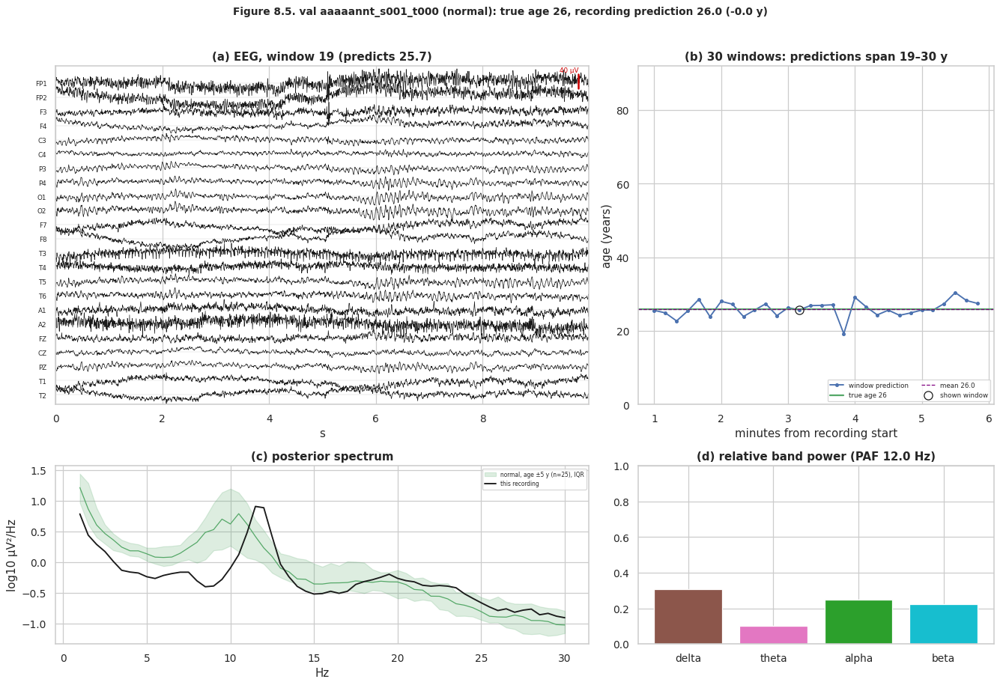

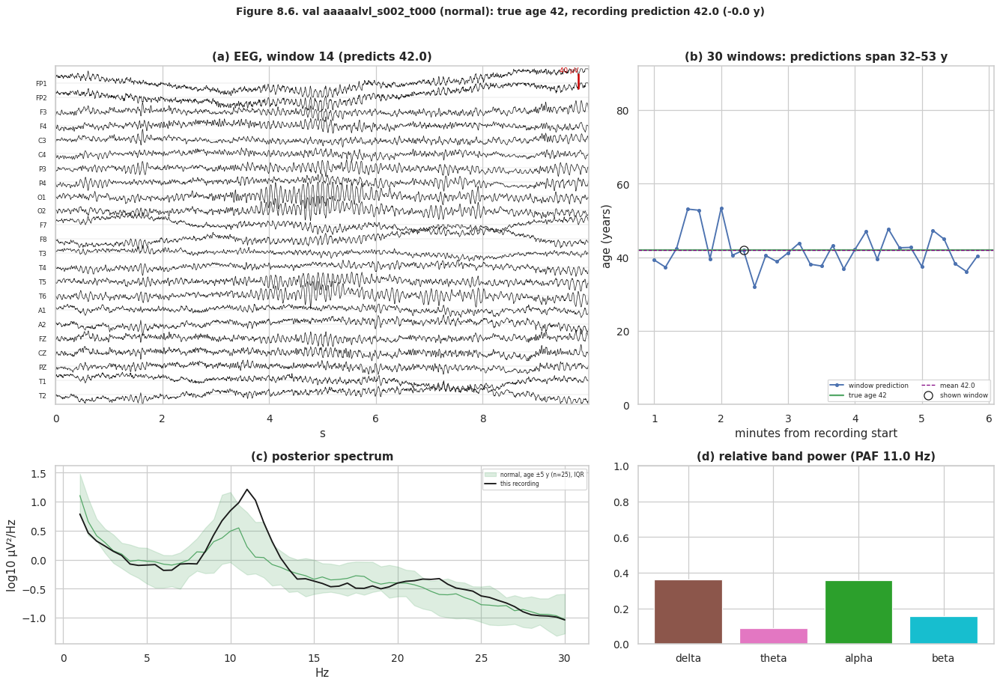

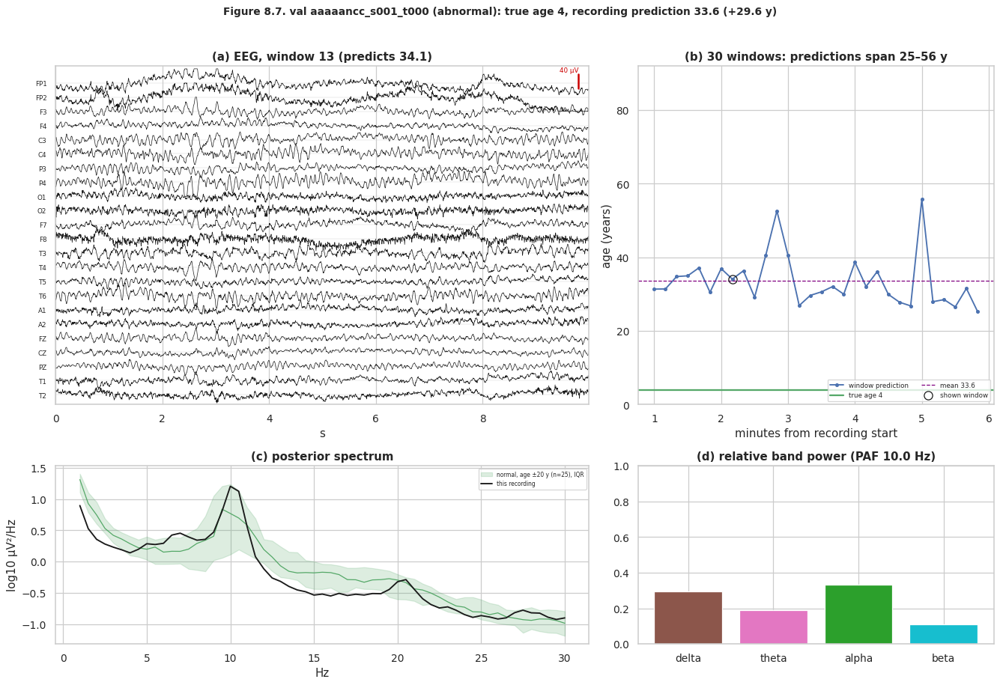

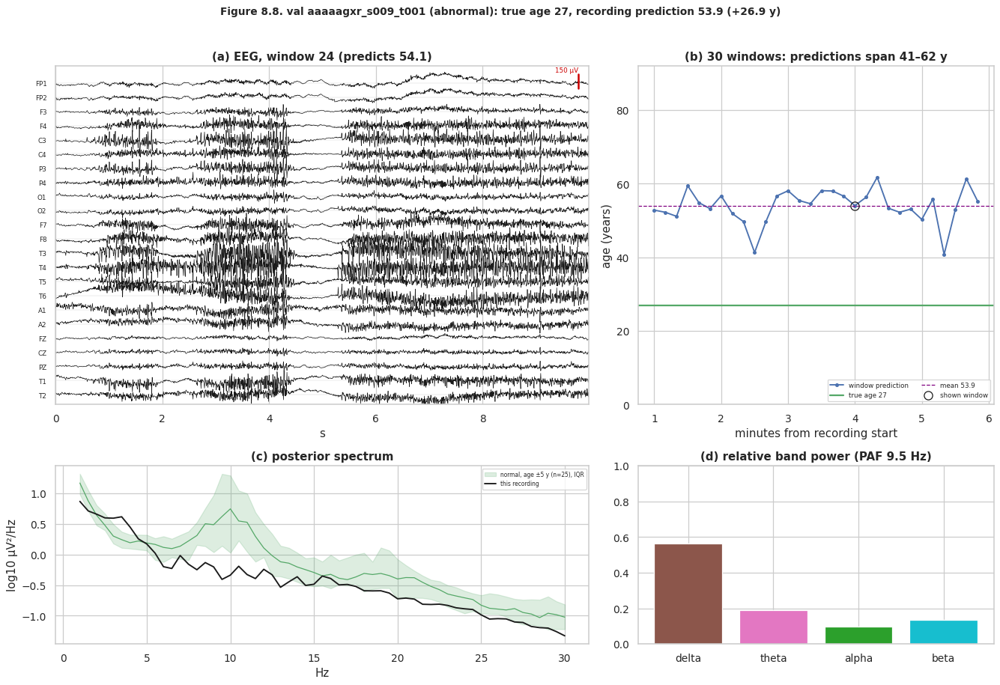

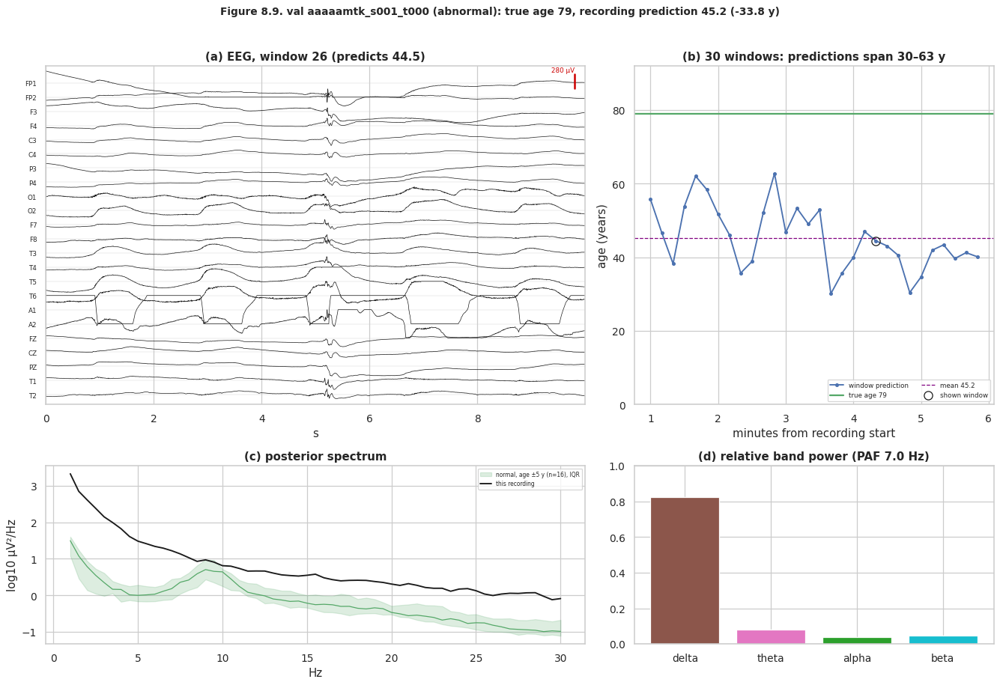

...

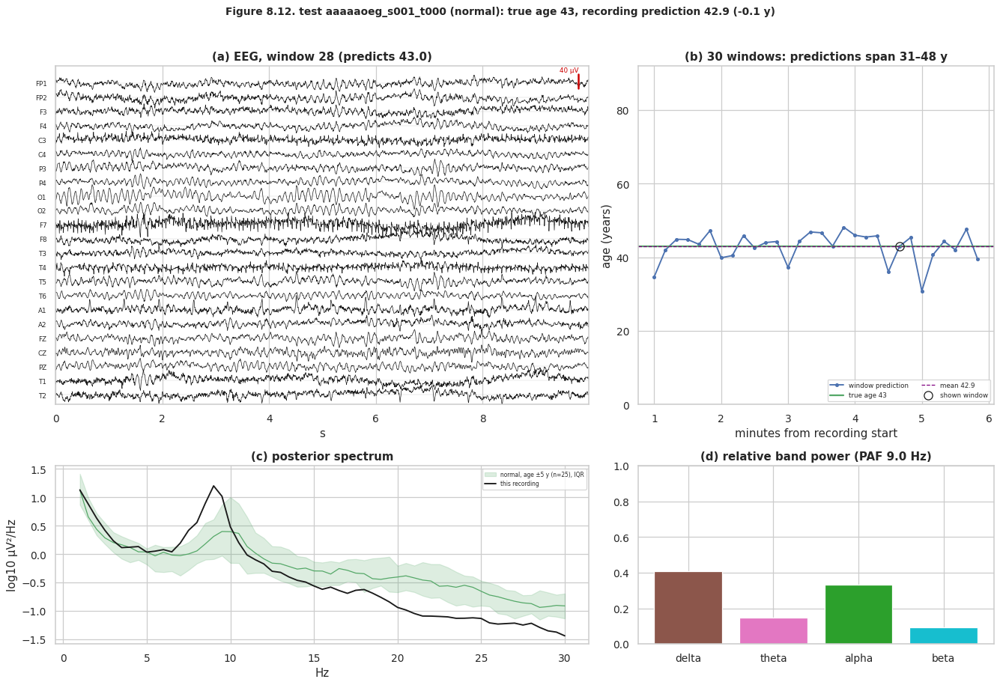

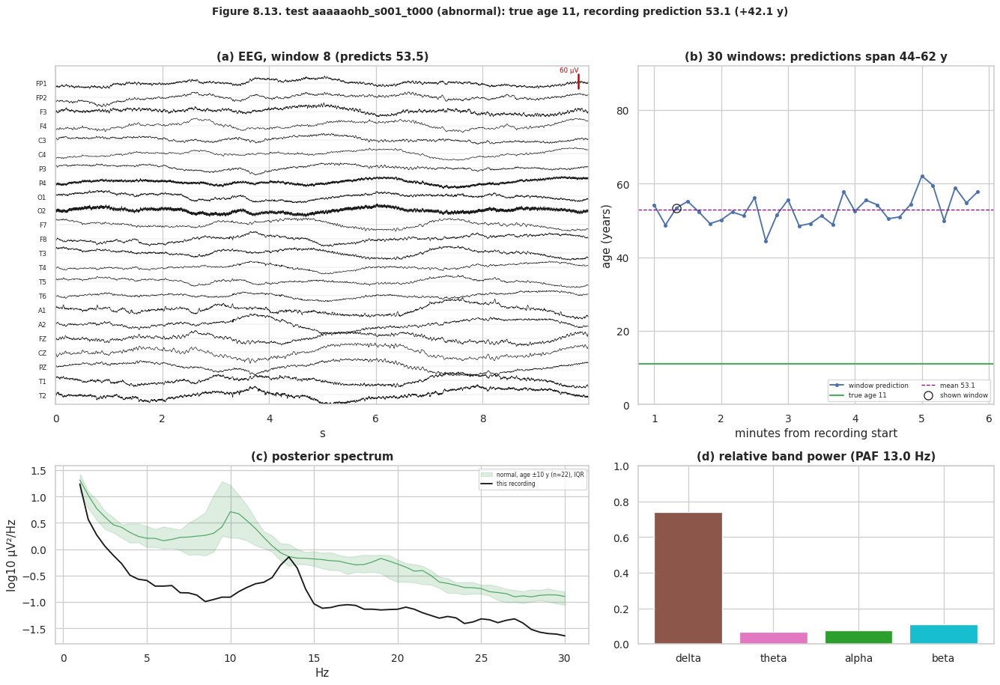

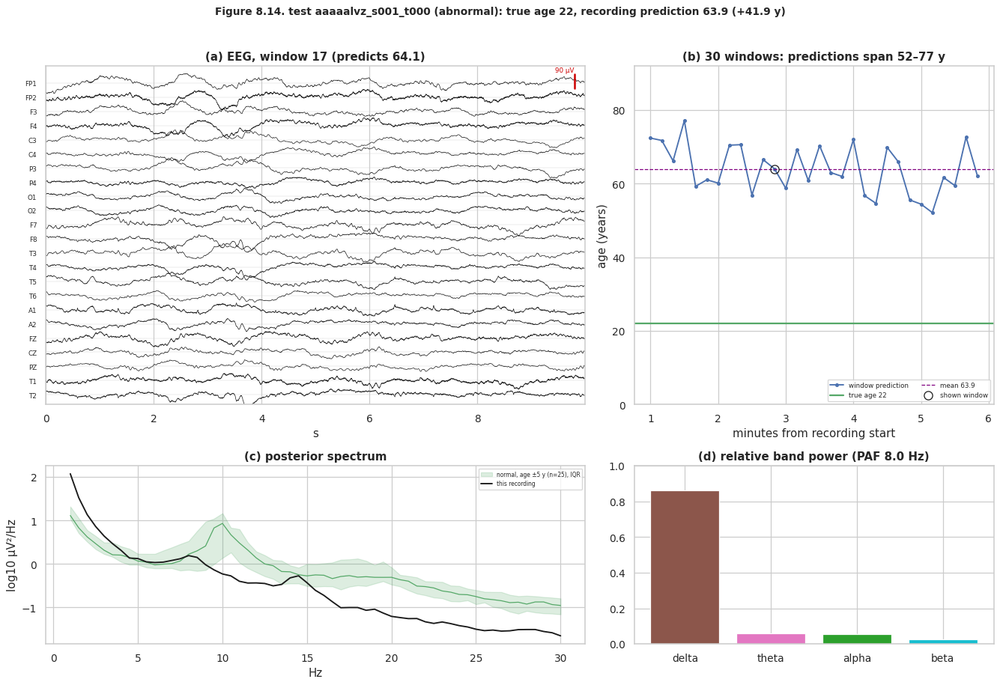

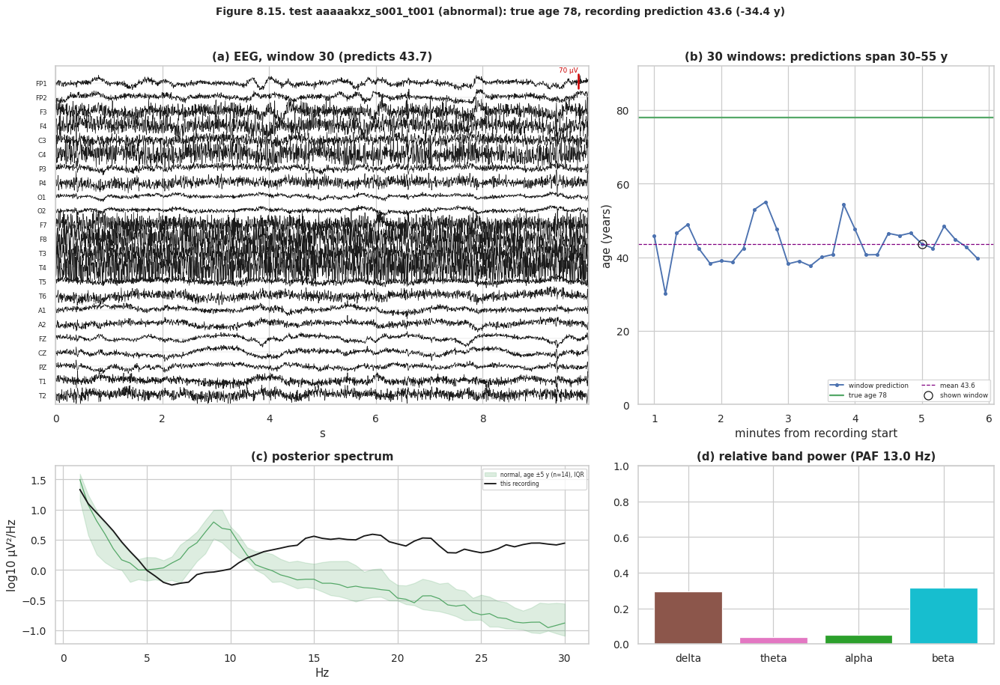

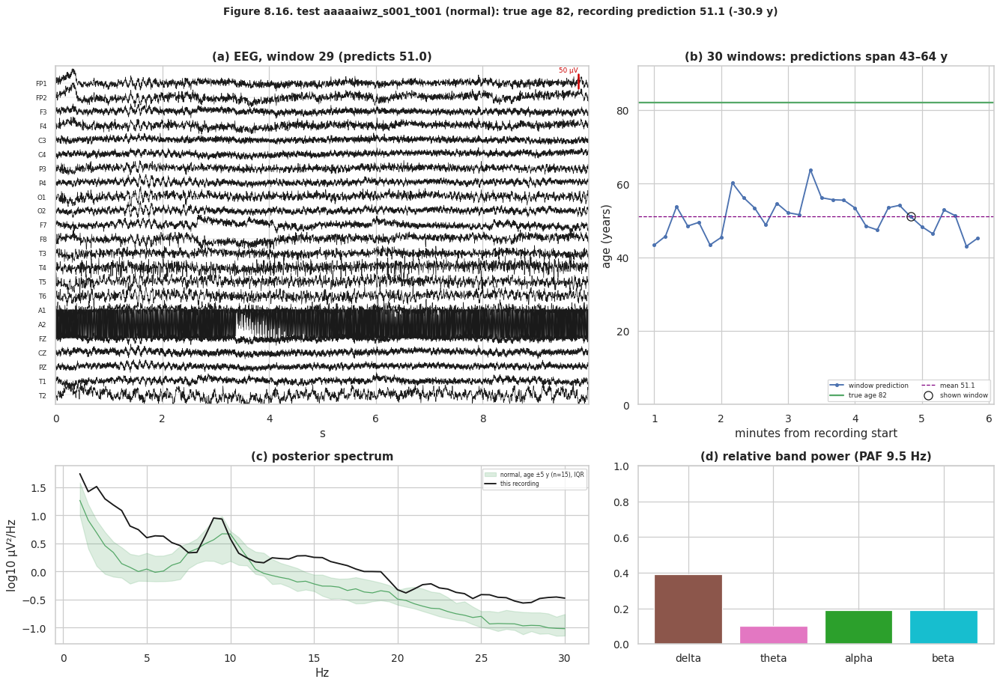

In [26]:
for k, (_, r) in enumerate(examples.iterrows()):
    fig = ex.show(r.recording, split=r.split, number=f"8.{first_no + k}")
    plt.show()

**What the extreme cases show (Table 8.1 and Figures 8.5 onward; M1, as executed).** Every one of the most over-predicted recordings
is *abnormal* and young: a 4-year-old predicted 34, an 11-year-old predicted 53, and a 22-year-old
predicted 64. The 22-year-old's spectrum has about 80% delta power and no alpha peak, which is
diffuse slowing that the model reads as an old brain. The most under-predicted are old (61–82 y),
mostly abnormal, and are pulled toward the mean. The best-predicted recordings are normal adults in
the dense 25–45 range.

### 8c. Interactive explorer

Pick split, outcome (over/under/accurate), cohort and true-age range; the recording list is sorted
by that outcome and shows *true age → predicted (error)*. Untick *representative window* to step
through all 30 windows with the slider; *channels* switches between the 10-20 set, posterior only
and all 23; *common average reference* and *clip artifacts* toggle the display. Its figure is captioned *Figure 8.E* (explorer). Needs a live
kernel; the saved notebook does not keep widget output.

In [27]:
ex.widget()

### 8d. Playground

Edit and re-run. The cells below produce Table 8.2 (candidates), **Figure 8.P1** (one
recording, posterior channels, first 5 s) and **Figure 8.P2** (a three-way comparison at 35).
Useful calls:

* `ex.find(age=70, tol=3, kind="under", cohort="normal", split="test", n=10)`: candidates as a
  table (`kind`: `"accurate"`, `"under"`, `"over"`, or `None` = sorted by age).
* `ex.show(recording, window=None, channels=None, seconds=(0, 10), car=True, clip=1.0)`: one
  recording. `window` is the position 0–29 in the recording; `channels` is a list such as
  `["O1", "O2", "PZ"]`; `seconds=(2, 6)` zooms in.
* `ex.compare_at_age(age, tol=3, cohort=None, split=None, channels=STANDARD_19)`: the three-way EEG
  comparison.
* `ex.windows_of(recording)`: every window's prediction; `ex.signal(split, idx)` returns the raw
  array (µV, `[23, 2000]`).

#### Table 8.2. Playground: candidate recordings

Normal recordings near 70 y, most under-predicted first.

In [28]:
display(numbered_table(ex.find(age=70, kind="under", cohort="normal", n=5), "8.2",
                       "playground: normal recordings near 70 y, most under-predicted first"))

,split,recording,cohort,age,pred,err,pred_std,n_windows,paf,rel_delta,rel_alpha
0,test,aaaaajje_s001_t000,normal,72.00,43.21,-28.79,5.76,30,9.00,0.38,0.28
1,test,aaaaajbh_s002_t000,normal,67.00,51.26,-15.74,4.92,30,9.50,0.18,0.32
2,test,aaaaaayx_s002_t000,normal,69.00,55.62,-13.38,3.99,30,9.00,0.42,0.17
3,val,aaaaaoma_s001_t000,normal,67.00,53.97,-13.03,3.81,30,10.00,0.45,0.42
4,test,aaaaalbt_s002_t000,normal,68.00,55.03,-12.97,4.97,30,8.50,0.35,0.22


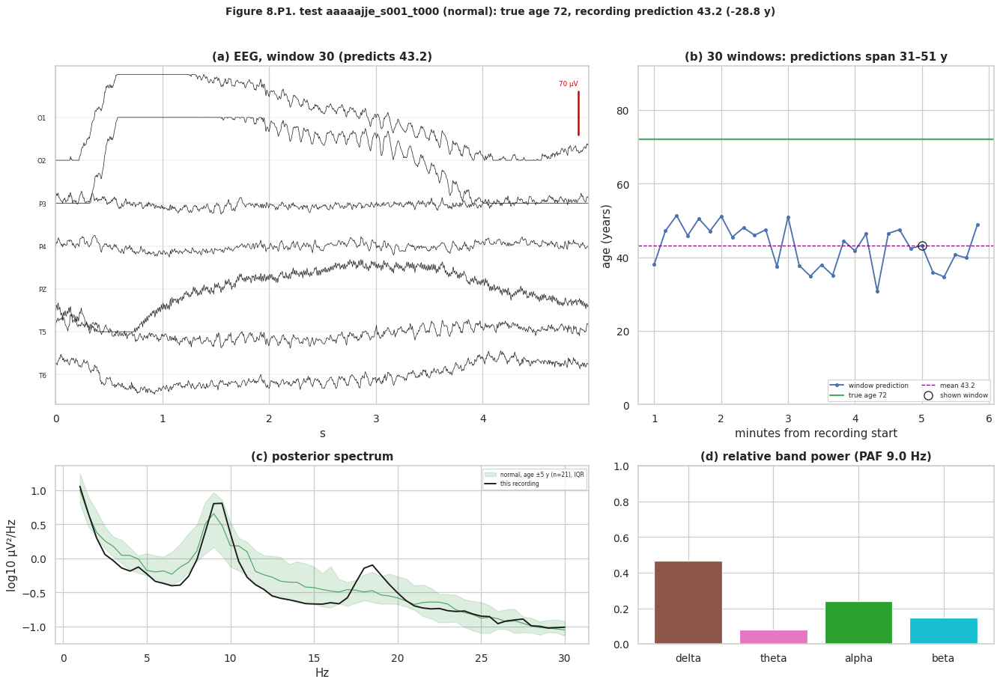

In [29]:
first = ex.find(age=70, kind="under", cohort="normal", n=1).iloc[0]
fig = ex.show(first.recording, channels=["O1", "O2", "P3", "P4", "PZ", "T5", "T6"], seconds=(0, 5),
              number="8.P1")
plt.show()

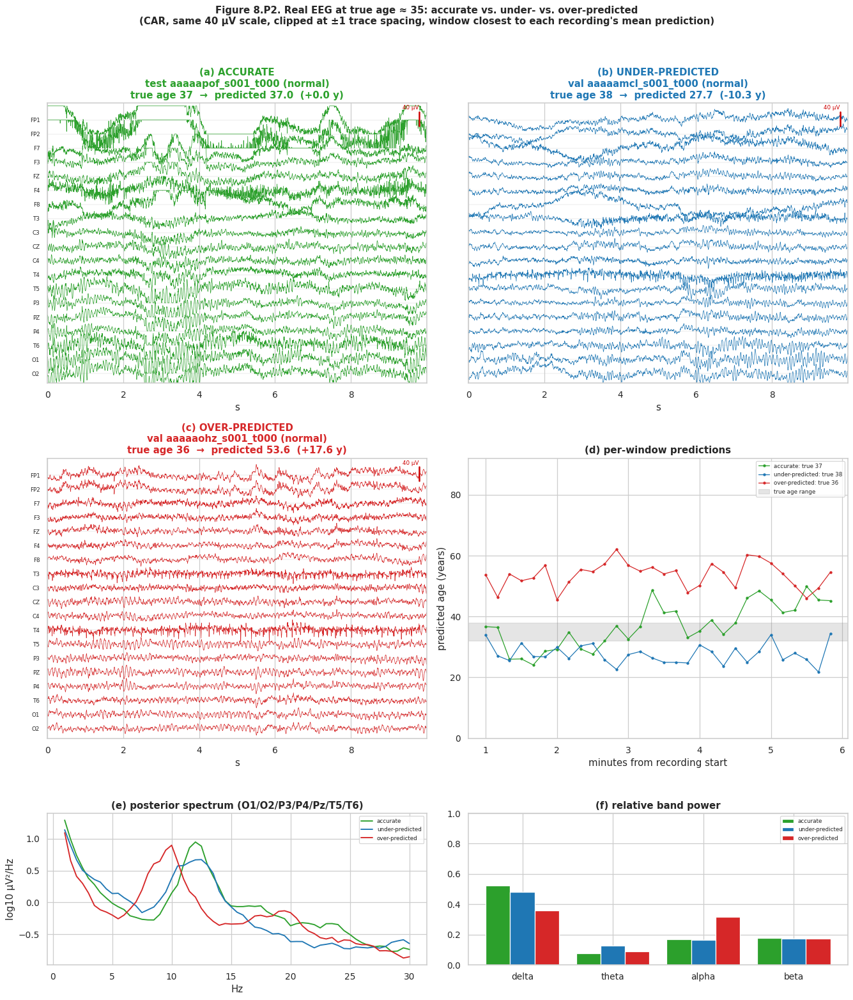

In [30]:
fig = ex.compare_at_age(35, cohort="normal", number="8.P2")
plt.show()

## 9. Run comparison: does any variant change the age-bin bias?

The same recording-level analysis for every available local run (val/test predictions are cached
per run). The short ablations that ran on SageMaker (EMA, LoRA, soft labels, dropout, …) are listed
in Table 9.1 from their ClearML summaries; their checkpoints are not local.

**Figure 9.1.** Test, per true-age decade (Eq. (5.2)): (a) mean predicted age, (b) MAE.

### Table 9.1. Short ablations from ClearML

Val/test recording MAE (Eq. (1.5)) and test MAE per cohort (Eq. (1.7)); checkpoints not local.

In [31]:
clearml_short = pd.DataFrame([
    ("E2 baseline (D, 4 ep)", 7.68, 8.25, None, None), ("M1 mixup 0.4", 7.46, 8.45, 6.60, 10.65),
    ("M1c C-Mixup σ=5", 7.54, 8.23, 6.50, 10.29), ("M12 mixup+EMA", 7.48, 8.45, 6.57, 10.69),
    ("M2 EMA eval", 7.58, 8.17, 6.35, 10.35), ("M3 LoRA r16", 7.68, 9.24, 7.41, 11.42),
    ("M4 soft labels", 7.67, 8.59, 6.92, 10.57), ("F1 layer decay 0.5", 7.74, 8.36, 6.42, 10.68),
    ("F2 dropout 0.1", 13.25, 15.17, 13.37, 17.32), ("F3 drop path 0.2", 7.70, 8.41, 6.31, 10.91),
    ("F4 weight decay 0.1", 7.66, 8.24, 6.49, 10.32), ("G1 head init 1.0", 7.76, 8.38, 6.64, 10.45),
    ("H1 layer decay 0.75", 7.71, 8.67, 6.64, 11.09), ("H2 layer decay 0.85", 7.86, 8.54, 6.74, 10.69),
], columns=["run", "val MAE", "test MAE", "test normal", "test abnormal"]).set_index("run")
display(numbered_table(clearml_short.style.format(precision=2, na_rep="–")
                       .highlight_min(subset=["val MAE", "test MAE"], color="#c7e9c0"),
                       "9.1", "short ablations from ClearML (recording MAE, years)"))

,val MAE,test MAE,test normal,test abnormal
run,,,,
"E2 baseline (D, 4 ep)",7.68,8.25,–,–
M1 mixup 0.4,7.46,8.45,6.60,10.65
M1c C-Mixup σ=5,7.54,8.23,6.50,10.29
M12 mixup+EMA,7.48,8.45,6.57,10.69
M2 EMA eval,7.58,8.17,6.35,10.35
M3 LoRA r16,7.68,9.24,7.41,11.42
M4 soft labels,7.67,8.59,6.92,10.57
F1 layer decay 0.5,7.74,8.36,6.42,10.68
F2 dropout 0.1,13.25,15.17,13.37,17.32


### Table 9.2. Local runs, recording level

MAE (2.1), median AE (2.2), $R^2$ (2.5), bias slope (2.9), and the sample std of the predicted and true ages,

$$
\mathrm{sd}(\hat y) = \sqrt{\frac{1}{R-1}\sum_r\big(\hat y_r-\overline{\hat y}\big)^2}
\tag{9.1}
$$

(a prediction sd below the true sd is regression to the mean).

In [32]:
comp_rows, comp_bins = [], {}
for name, d in COMPARE.items():
    rd = resolve_run_dir(d)
    # checkpoint-best.pth exists from the first epoch on; only finished runs count.
    if not rd or not os.path.exists(os.path.join(rd, "checkpoint-final.pth")):
        print(f"skip {name}: no finished run yet")
        continue
    r = per_recording(cached_predictions(rd, splits=("val", "test")))
    for split in ("val", "test"):
        s = regression_summary(r[r.split == split])
        d = r[r.split == split]
        comp_rows.append({"run": name, "split": split, **{k: s[k] for k in
                          ("mae", "median_ae", "r2", "bias_slope")},
                          "pred sd": d.pred.std(), "true sd": d.age.std()})
    comp_bins[name] = error_by_age_bin(r[r.split == "test"])
comp = pd.DataFrame(comp_rows).pivot(index="run", columns="split")
display(numbered_table(comp, "9.2", "local runs, recording level (Eqs. 2.1, 2.2, 2.5, 2.9, 9.1)"))

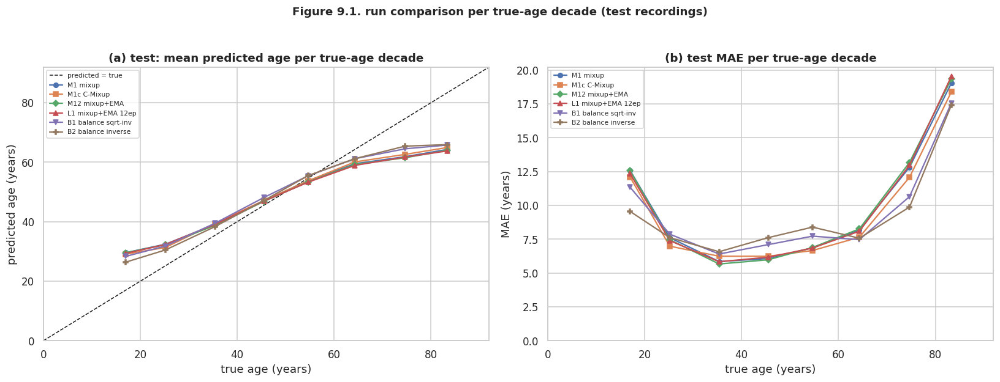

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
identity(ax[0])
markers = "osD^vP*X"
for k, (name, b) in enumerate(comp_bins.items()):
    b = b[b.n >= 3]
    ax[0].plot(b.age_mean, b.pred_mean, marker=markers[k % len(markers)], ms=5, label=name)
    ax[1].plot(b.age_mean, b.mae, marker=markers[k % len(markers)], ms=5, label=name)
ax[0].set(title="test: mean predicted age per true-age decade", xlabel="true age (years)",
          ylabel="predicted age (years)")
ax[1].set(title="test MAE per true-age decade", xlabel="true age (years)", ylabel="MAE (years)",
          xlim=AGE_LIM, ylim=(0, None))
for a in ax: a.legend(fontsize=7, loc="upper left")
panel_labels(ax)
figure_caption(fig, "9.1", "run comparison per true-age decade (test recordings)")
plt.tight_layout(); plt.show()

### Table 9.3. Mean predicted age per true-age decade

The numbers behind Figure 9.1(a), test recordings.

In [34]:
display(pd.DataFrame({name: b.pred_mean for name, b in comp_bins.items()})
        .assign(**{"true (mean age)": next(iter(comp_bins.values())).age_mean})
        .rename_axis("test decade").style.format(precision=1)
        .pipe(numbered_table, "9.3", "mean predicted age per true-age decade (test recordings)"))

,M1 mixup,M1c C-Mixup,M12 mixup+EMA,L1 mixup+EMA 12ep,B1 balance sqrt-inv,B2 balance inverse,true (mean age)
test decade,,,,,,,
10-19,29.6,29.1,29.6,29.3,28.3,26.4,17.0
20-29,32.4,31.3,32.3,32.3,31.8,30.5,25.2
30-39,39.0,39.4,38.7,39.1,39.4,38.3,35.4
40-49,47.1,47.1,46.8,46.9,48.1,47.1,45.5
50-59,53.7,53.7,53.4,53.3,55.4,55.5,54.6
60-69,59.5,60.1,59.2,58.9,61.2,61.2,64.3
70-79,61.8,62.6,61.5,61.7,64.5,65.4,74.7
80-89,64.3,64.9,64.0,63.8,65.7,65.9,83.3


### Age-balanced loss (B1 = sqrt-inverse, B2 = inverse weights; short schedule, no mixup)

As executed.
The loss of Eq. (0.6) becomes a weighted mean. With $N_k$ the number of train windows in the 1-year age
bin $k(i)$ of window $i$:

$$
\mathcal{L} = \frac{1}{B}\sum_{i=1}^{B} \omega_{k(i)}\,\ell_\delta\!\left(\hat z_i - z_i\right),
\qquad
\omega_k \propto \begin{cases} N_k^{-1/2} & \text{B1 (sqrt-inverse)}\\ N_k^{-1} & \text{B2 (inverse)}\end{cases}
\tag{9.2}
$$

The weights are capped at `balance_max_weight` × the smallest weight and normalised to mean 1 over
the train windows (`losses/regression.py::age_balance_weights`).

The balanced loss moves the tails toward the diagonal, but only partly, and it costs accuracy in the
dense middle:

### Table 9.4. Balanced loss: test mean predicted age per decade

Test mean predicted age per true-age decade (Eq. (5.2)) for M1 and the two balanced runs.

| test decade (true mean age) | M1 mixup | B1 sqrt-inv | B2 inverse |
|---|---|---|---|
| 10–19 (17) | predicted 29.6 | 28.3 | **26.4** |
| 20–29 (25) | 32.4 | 31.8 | 30.5 |
| 50–59 (55) | 53.7 | 55.4 | 55.5 |
| 70–79 (75) | 61.8 | 64.5 | **65.4** |
| 80–89 (83) | 64.3 | 65.7 | 65.9 |

* Prediction spread widens (test pred sd 13.4 → 14.6 / 15.6, true 18.1) and the bias slope shrinks
  (val −0.37 → −0.32 / −0.29).
* Per-decade MAE improves where the weights are large (B2, 10–19: 12.6 → 9.6; 70–79: 12.8 → 9.9)
  and worsens where they are small (40–59: ~6.0–6.9 → 7.6–8.4). Overall MAE goes up: val 7.83 / 7.96 and
  test 8.47 / 8.57, against 7.68 / 8.25 for the matching no-mixup baseline E2.
* The 80–89 decade barely moves (+1.5 y). Reweighting cannot create information that the EEG of the
  oldest recordings does not carry (section 7: slowing and pathology dominate there).

**Use it when** the downstream use needs less age-dependent bias (e.g. brain-age gap across the
age range) more than the lowest MAE. **Not** as a way to lower MAE.

## 10. Takeaways

The narrative is written against the executed outputs above; equation, table and figure numbers refer
to them. Rerun the notebook after new runs
finish; section 9 picks them up automatically.

In [35]:
s_val, s_test, s_train = (regression_summary(d) for d in (val, test, train))
params = fit_bias_correction(val.pred, val.age)
cole = regression_summary(test.assign(pred=apply_bias_correction(test.pred, params, "cole")))
by_bin = error_by_age_bin(test)
print(f"* Memorization: recording MAE train {s_train['mae']:.2f} (eval mode) vs val {s_val['mae']:.2f} "
      f"/ test {s_test['mae']:.2f}.")
print(f"* Mean vs median: test MAE {s_test['mae']:.2f}, median AE {s_test['median_ae']:.2f}, "
      f"P90 {s_test['p90_ae']:.2f}; the tail is concentrated in the oldest bins and abnormal recordings.")
print(f"* Regression to the mean: test bias slope {s_test['bias_slope']:.2f}; the {by_bin.index[0]} "
      f"decade (mean age {by_bin.age_mean.iloc[0]:.0f}) is predicted {by_bin.pred_mean.iloc[0]:.0f}, the "
      f"{by_bin.index[-1]} decade (mean age {by_bin.age_mean.iloc[-1]:.0f}) is predicted "
      f"{by_bin.pred_mean.iloc[-1]:.0f}; predictions span sd {test.pred.std():.1f} vs true sd {test.age.std():.1f}.")
print(f"* Calibration: on val, age ≈ {params['recal_a']:.2f}·pred {params['recal_b']:+.2f}, so predictions "
      f"are already E[age | pred]. Cole's inversion removes the slope ({cole['bias_slope']:.2f}) but raises "
      f"test MAE to {cole['mae']:.2f}.")
print(f"* Cohort: test MAE normal {regression_summary(test[test.cohort == 'normal'])['mae']:.2f} vs "
      f"abnormal {regression_summary(test[test.cohort == 'abnormal'])['mae']:.2f}.")

* Memorization: recording MAE train 4.31 (eval mode) vs val 7.46 / test 8.45.
* Mean vs median: test MAE 8.45, median AE 6.78, P90 17.72; the tail is concentrated in the oldest bins and abnormal recordings.
* Regression to the mean: test bias slope -0.41; the 10-19 decade (mean age 17) is predicted 30, the 80-89 decade (mean age 83) is predicted 64; predictions span sd 13.4 vs true sd 18.1.
* Calibration: on val, age ≈ 1.00·pred +0.46, so predictions are already E[age | pred]. Cole's inversion removes the slope (-0.08) but raises test MAE to 9.94.
* Cohort: test MAE normal 6.60 vs abnormal 10.65.


**Interpretation**

* **The bias is not a calibration bug** (Table 6.1). Linearly regressing age on the prediction (Eq. (6.1)) gives slope $\alpha\approx 1$, so the
  model already outputs roughly E[age | EEG]. Regression to the mean is what a squared/Huber-loss estimator
  does when the EEG carries limited age information. No deployable post-hoc correction lowers the MAE.
  Cole's correction trades a flat bias for a higher MAE, and the "age-level" correction only looks good
  because it uses the true age.
* **The errors concentrate in the tails of the age distribution and in the abnormal cohort** (Figures 3.1, 5.1). The
  10% worst windows carry about 45% of the Huber loss. Sampling density explains part of it: the bins
  with the fewest train windows (<20 y: ~8k; 70–79: 24k; 80–89: 13k, vs. ~40–55k for 20–69) have the
  largest MAE. But density is not the whole story. 20–29 and 60–69 have nearly the same train counts
  (~40k windows), yet on test the 20–29-year-olds are predicted ~7 years too old and the 60–69-year-olds
  ~5 years too young, and 80–89 is worse than 10–19 despite more data. Even on **train** the
  predicted-vs-true fit slope is 0.80, so the shrinkage is built into the fit, not only a val/test
  effect.
* **Pathological slowing reads as "older"** (Table 7.2, Figure 7.1). After removing the age trend, the residual correlates with
  lower posterior PAF (ρ ≈ −0.2) and a higher theta/alpha ratio (+0.17). Abnormal recordings sit at a
  median PAF of 7.5 Hz vs. 10 Hz for normal ones. Among age-matched 40–69-year-olds, 72% of the most
  over-predicted fifth are abnormal vs. 43% of the most under-predicted. Within the abnormal cohort,
  delta power and theta/alpha drive the over-prediction; within the normal cohort the effect is weak.
  The model partly confuses disease-related slowing with ageing. This is a property of the data rather
  than a modelling bug, so the brain-age gap on abnormal EEG is partly a pathology signal.
* **Within-recording spread is a weak confidence signal** (r ≈ 0.1 with the error), and median pooling
  does not beat mean pooling.
* **Levers that can actually move the tails**: an age-balanced loss (B1/B2, section 9), which accepts
  a higher MAE in the dense middle for less tail bias; longer training with mixup+EMA (L1); and, for
  the abnormal cohort, conditioning on or modelling pathology (e.g. a normal/abnormal auxiliary head)
  instead of hoping the age head ignores it.